# Coupler lookup analysis

Reads `coupler_lookup_tables.pkl` and produces three groups of plots:

1. **Frequency lookups + coupling extraction** — `f0g1(I)` and `f_coupler(I)` measurements vs their polynomial models, dressed manipulate frequency `ω_m(I) = ω_gf − f0g1(I)`, and a fit of the dispersive Lamb shift `ω_m(I) = ω_m_bare + g²/(ω_m_bare − ω_c(I))` to extract the manipulate–coupler coupling `g`.
2. **Rabi gain coefficient** — `k_per_DAC(I)` (Rabi rate per DAC unit) from the per-current characterization.
3. **Coherence** — `T1(I)` and `T2(I)` of the coupler, color-coded by extraction regime (`long_T2` Ramsey vs `short_T2` spec‐vs‐power).

## Setup

Edit `LOOKUP_PATH` and `OMEGA_GF_MHZ` below. `ω_gf` is the (current‐independent) qubit `g↔f` transition frequency in MHz — needed because

$$ f_{0g1}(I) \;=\; \omega_{gf} \,-\, \omega_{m}^{\rm dressed}(I) , $$

so `ω_m_dressed(I) = ω_gf − f0g1(I)`. A wrong `ω_gf` shifts every `ω_m` by a constant, which is absorbed into the fitted `ω_m_bare` — it does *not* change the extracted `g` (only its physical interpretation of `ω_m_bare`).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from experiments import MultimodeStation

LOOKUP_PATH = Path(r'C:\experiments\260420_T2_AC_stark\data\coupler_lookup_tables.pkl')

USER = 'seb'
EXPERIMENT_NAME = '260526_Transduction'

# log_measurements=True wires every queue-side run() into the lab notebook (vault).
# Per-point logging in the inner sweeps can be silenced with `log=False` on run().
station = MultimodeStation(
    user=USER,
    experiment_name=EXPERIMENT_NAME,
    project='Transduction',
    log_measurements=True,
    mock=True
)

OMEGA_GF_MHZ = station.hardware_cfg.device.qubit.f_ge[0] + station.hardware_cfg.device.qubit.f_ef[0]

with open(LOOKUP_PATH, 'rb') as f:
    data = pickle.load(f)

print('Top‐level keys:', list(data.keys()))
print('Per‐current entries:', len(data.get('characterization', {})))

Failed to read module file 'C:\python\multimode_expts\.pixi\envs\default\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", li

Importing all classes from  C:\python\multimode_expts\experiments\dual_rail
Importing all classes from  C:\python\multimode_expts\experiments\qsim
Importing all classes from  C:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  C:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
[STATION] Using main hardware_config version: CFG-HW-20260526-00050
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260526-00013
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00024
Creating or updating new csv at path: CFG-FL-20260223-00024.csv


C:\python\multimode_expts\experiments\dataset.py:88: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.df = pd.concat([self.df, pd.DataFrame(rows)], ignore_index=True)


OSError: Cannot save file into a non-existent directory: 'D:\python\multimode_expts\configs\versions\floquet_storage_swap'

In [ ]:
# Flux <-> current calibration.
# Anchor points (user-supplied): phi=0   <->  I = -0.21 mA
#                                phi=0.5 <->  I =  0.75 mA
# Linear map: phi(I) = (I - I0) / (2 * (I_half - I0))
PHI_I0_MA      = -0.21      # current at phi/phi0 = 0
PHI_IHALF_MA   =  0.75      # current at phi/phi0 = 0.5
_PHI_SLOPE     = 2.0 * (PHI_IHALF_MA - PHI_I0_MA)   # mA per phi0

def I_to_phi(I_mA):
    return (np.asarray(I_mA, dtype=float) - PHI_I0_MA) / _PHI_SLOPE

def phi_to_I(phi):
    return PHI_I0_MA + np.asarray(phi, dtype=float) * _PHI_SLOPE

def add_current_top_axis(ax, label='I (mA)'):
    """Add a top secondary x-axis showing current, given a primary axis in phi/phi0."""
    secax = ax.secondary_xaxis('top', functions=(phi_to_I, I_to_phi))
    secax.set_xlabel(label)
    return secax

print(f'phi/phi0 mapping: 1 phi0 = {_PHI_SLOPE:.4f} mA  '
      f'(phi=0 at I={PHI_I0_MA} mA, phi=0.5 at I={PHI_IHALF_MA} mA)')

phi/phi0 mapping: 1 phi0 = 1.9200 mA  (phi=0 at I=-0.21 mA, phi=0.5 at I=0.75 mA)


In [10]:
def flatten_characterization(data):
    """Pull per-current scalars into parallel numpy arrays sorted by current."""
    char = data.get('characterization', {})
    rows = []
    for I, e in char.items():
        T1 = e.get('T1', {})
        anh = e.get('anharm', {})
        man = e.get('manipulate', {}) or {}
        T2_long_nested = e.get('T2_long') or {}
        T2_short_nested = e.get('joint_short_T2') or e.get('T2_short') or {}
        rows.append({
            'I_mA':                 float(I),
            'f0g1_MHz':             e.get('f0g1_MHz', np.nan),
            'f_coupler_MHz':        e.get('f_coupler_MHz', np.nan),
            'T1_us':                T1.get('T1_us', np.nan),
            'T1_err_us':            T1.get('T1_err_us', np.nan),
            'T2_short_us':          e.get('T2_short_us', T2_short_nested.get('T2_us', np.nan)),
            'T2_long_us':           e.get('T2_long_us', T2_long_nested.get('T2_ramsey_us', np.nan)),
            'k_per_DAC':            e.get('k_per_DAC', np.nan),
            'regime':               e.get('regime', '?'),
            'anharm_MHz':           anh.get('anharmonicity_MHz', np.nan),
            'T1_manipulate_us':     man.get('T1_us', e.get('T1_manipulate', np.nan)),
            'T2_ramsey_manipulate_us': man.get('T2_ramsey_us', e.get('T2_ramsey_manipulate', np.nan)),
            'T2_echo_manipulate_us':   man.get('T2_echo_us',   e.get('T2_echo_manipulate', np.nan)),
        })
    rows.sort(key=lambda r: r['I_mA'])
    keys = rows[0].keys() if rows else []
    out = {k: np.array([r[k] for r in rows]) for k in keys}
    return out

char = flatten_characterization(data)
for k in ('I_mA', 'f0g1_MHz', 'f_coupler_MHz', 'T1_us', 'T2_short_us', 'T2_long_us', 'k_per_DAC', 'regime',
          'T1_manipulate_us', 'T2_ramsey_manipulate_us', 'T2_echo_manipulate_us'):
    print(f'{k:>26}: {char[k]}')


                      I_mA: [-0.27  -0.265 -0.26  -0.255 -0.25  -0.245 -0.24  -0.235 -0.23  -0.225
 -0.22  -0.215 -0.21  -0.205 -0.2   -0.19  -0.185 -0.18  -0.175 -0.17
 -0.165 -0.16  -0.155 -0.15  -0.125 -0.1   -0.075 -0.05  -0.025  0.
  0.05   0.1    0.15   0.2    0.25   0.28   0.29   0.3    0.32   0.35
  0.4  ]
                  f0g1_MHz: [          nan           nan           nan           nan 1968.11538305
           nan           nan           nan           nan 1967.64252699
           nan           nan           nan           nan 1967.62069881
           nan           nan           nan 1968.00006373 1968.11972655
           nan           nan           nan 1968.73129175 1969.76586069
 1971.05635928           nan 1974.22287319 1976.01234808 1977.88527787
 1981.73518844 1985.5110889  1989.00803031 1992.08732893 1994.68626438
           nan           nan 1996.82777781           nan           nan
           nan]
             f_coupler_MHz: [          nan           nan           nan  

## 1. Frequency lookups

The pickle stores polynomial fits in `data['f0g1_fine']` and `data['coupler']` (keys `currents_mA`, `peaks_MHz`, `coeffs`, `deg`). Below we overlay those models with both their seed peak measurements and the per-current values logged in `data['characterization']`.

In [11]:
def poly_section(data, key):
    sec = data[key]
    coeffs = np.asarray(sec['coeffs'])
    return {
        'coeffs': coeffs,
        'deg': int(sec['deg']),
        'currents_mA': np.asarray(sec['currents_mA'], dtype=float),
        'peaks_MHz':   np.asarray(sec['peaks_MHz'],   dtype=float),
        'func': np.poly1d(coeffs),
    }

f0g1_sec = poly_section(data, 'f0g1_fine')
coup_sec = poly_section(data, 'coupler')

I_min = min(f0g1_sec['currents_mA'].min(), coup_sec['currents_mA'].min(), char['I_mA'].min())
I_max = max(f0g1_sec['currents_mA'].max(), coup_sec['currents_mA'].max(), char['I_mA'].max())
I_dense = np.linspace(I_min, I_max, 401)

print(f'f0g1 polyfit deg={f0g1_sec["deg"]}, {len(f0g1_sec["currents_mA"])} seed points')
print(f'coupler polyfit deg={coup_sec["deg"]}, {len(coup_sec["currents_mA"])} seed points')

f0g1 polyfit deg=5, 10 seed points
coupler polyfit deg=8, 52 seed points


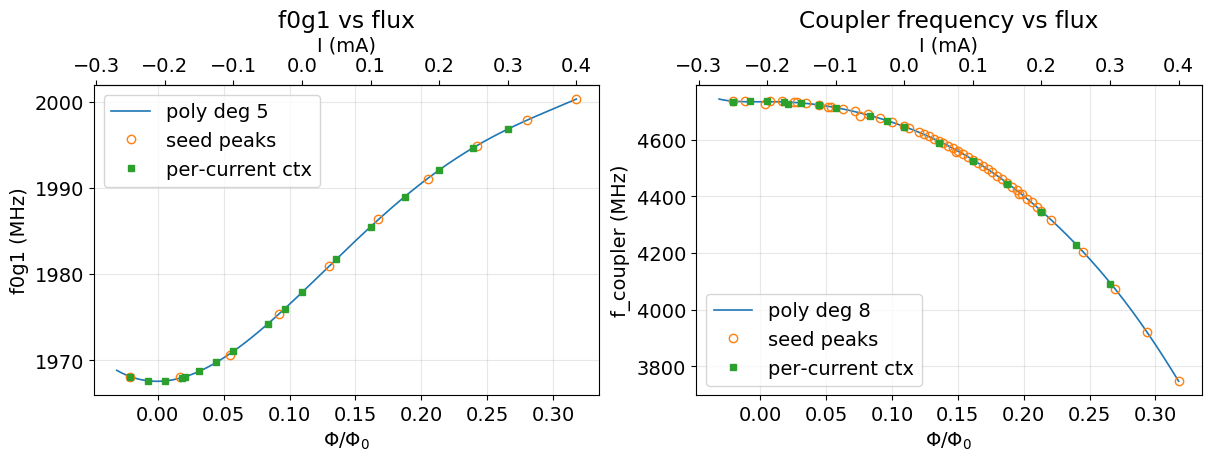

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(I_to_phi(I_dense), f0g1_sec['func'](I_dense), '-', lw=1.2, label=f'poly deg {f0g1_sec["deg"]}')
ax.plot(I_to_phi(f0g1_sec['currents_mA']), f0g1_sec['peaks_MHz'], 'o', mfc='none', label='seed peaks')
ax.plot(I_to_phi(char['I_mA']), char['f0g1_MHz'], 's', ms=5, label='per‐current ctx')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('f0g1 (MHz)')
ax.set_title('f0g1 vs flux'); ax.legend(); ax.grid(alpha=0.3)
add_current_top_axis(ax)

ax = axes[1]
ax.plot(I_to_phi(I_dense), coup_sec['func'](I_dense), '-', lw=1.2, label=f'poly deg {coup_sec["deg"]}')
ax.plot(I_to_phi(coup_sec['currents_mA']), coup_sec['peaks_MHz'], 'o', mfc='none', label='seed peaks')
ax.plot(I_to_phi(char['I_mA']), char['f_coupler_MHz'], 's', ms=5, label='per‐current ctx')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('f_coupler (MHz)')
ax.set_title('Coupler frequency vs flux'); ax.legend(); ax.grid(alpha=0.3)
add_current_top_axis(ax)

plt.show()

### Lamb shift → manipulate–coupler coupling `g`

From the dispersive limit (manipulate cavity coupled to a single coupler mode):

$$ \omega_m^{\rm dressed}(I) \;=\; \omega_m^{\rm bare} \;+\; \frac{g^2}{\omega_m^{\rm bare} \,-\, \omega_c(I)} . $$

We measure the LHS via `ω_m_dressed(I) = ω_gf − f0g1(I)` and `ω_c(I)` directly from coupler spectroscopy. Two free parameters: `g` and `ω_m_bare`.

> The simple two‐level form above ignores transmon‐coupler levels above `|e⟩`. If you want the multi‐level dispersive correction (uses the measured coupler anharmonicity), set `USE_TRANSMON_CORRECTION = True` in the next cell:
>
> $$ \omega_m^{\rm dressed}(I) \;=\; \omega_m^{\rm bare} + \frac{g^2 \, \alpha}{\Delta(I)\,(\Delta(I)+\alpha)}, \qquad \Delta = \omega_m^{\rm bare} - \omega_c(I) . $$
>
> `α` (negative for a transmon) is taken as the median of the per‐current `anharm_MHz` entries that are finite — only populated for the long‐T2 currents.

### anharmonicity as a fitting parameter

### Hybridization shading

The Lamb fit above is exact (limited only by Fock cutoffs), so there is no analytical-expansion validity to flag. What still matters for the $T_2$-vs-flux-noise inversion is whether the dressed manipulate-like state is *actually* mostly manipulate.

We define **manipulate purity** $P_m(\Phi) = |\langle 0,1|\psi_{\rm dressed}\rangle|^2$ for the eigenstate adiabatically connected to the bare $|0,1\rangle$. Far from the avoided crossing $P_m \to 1$; near it $P_m \to 1/2$ as the dressed state becomes a 50/50 hybrid with the coupler-like $|1,0\rangle$. Inside the shaded band ($P_m < $ `PURITY_THRESHOLD`, default 0.95) the manipulate inherits coupler T1 / T2, so the *measured* $T_1^{\rm manip}$ already reflects the hybridization, but the implied $A_\Phi$ should be read with care.

The cell below caches a dense num-diag grid in $\Phi$ and exposes `shade_hybrid(ax, threshold=...)` for downstream plots.


ω_m_bare = 4977.903 ± 0.284 MHz
g        = 97.893 ± 0.400 MHz
α        = 30.380 MHz   (FIXED, Duffing positive sign)
(num-diag, N_c=4, N_m=10, CR=off, n=17 points used)
coupler Lamb shift (ω_c_bare − ω_c_dressed): mean +29.62 MHz, max |39.78| MHz


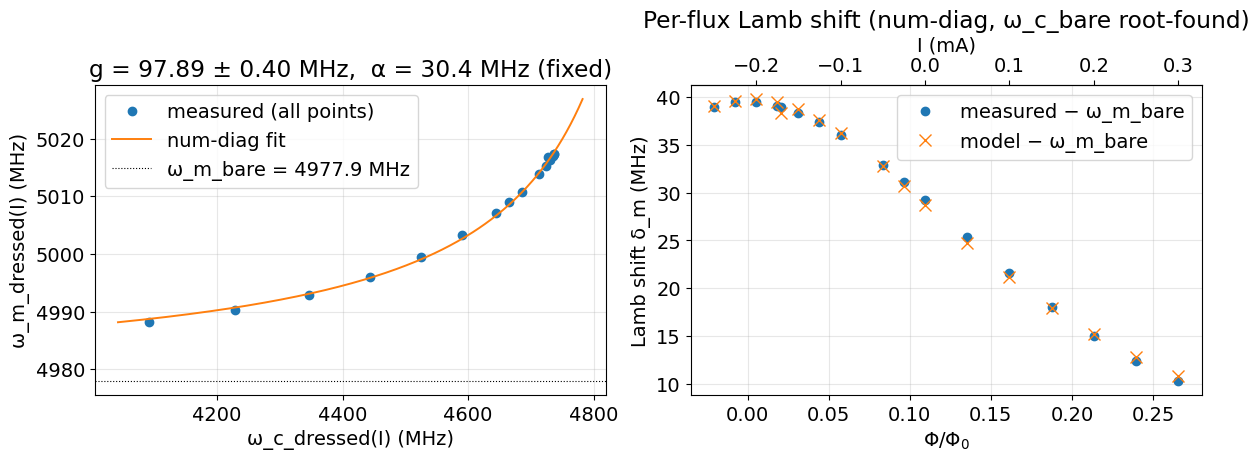

Building dense num-diag grid (~few seconds)...


In [13]:
from scipy.linalg import eigh
from scipy.optimize import brentq

# Numerical-diagonalization Lamb fit — proper version.
# Per measurement point we have BOTH measured dressed frequencies:
#   - ω_c_dressed_i  (from coupler spec)            -> char['f_coupler_MHz']
#   - ω_m_dressed_i  (from f0g1: OMEGA_GF − f0g1)   -> wm_arr
# Inner per-row step: root-find ω_c_bare_i so the diagonalization predicts
# ω_c_dressed_i. With those bare values the model predicts ω_m_dressed_i,
# which the global curve_fit minimizes against the measurement.
# Free GLOBAL params: ω_m_bare, g.  α is fixed (Duffing positive convention).

USE_NUMDIAG = True
INCLUDE_CR  = False     # counter-rotating (Bloch-Siegert ~ g^2/(wm+wc))
N_COUPLER   = 4         # coupler Fock cutoff (>=3 to feel α)
N_MANIP     = 10        # manipulate Fock cutoff (>=2; 3 for safety)

# --- Coupler anharmonicity: fixed from a direct measurement (see Step 3 in
# coupler_systematic_study, "Anharmonicity from spec-vs-gain"). To leading
# order α ~ -E_C is flux-independent.
ALPHA_FIXED_MHZ = 30.38
# Alternative: ALPHA_FIXED_MHZ = float(np.nanmedian(char['anharm_MHz']))


I_arr  = char['I_mA']
fc_arr = char['f_coupler_MHz']         # MEASURED dressed ω_c
fg_arr = char['f0g1_MHz']
wm_arr = OMEGA_GF_MHZ - fg_arr         # MEASURED dressed ω_m

good = np.isfinite(fc_arr) & np.isfinite(fg_arr)
I_arr, fc_arr, wm_arr = I_arr[good], fc_arr[good], wm_arr[good]


# --- Operator setup (precomputed) ---
def _ladder(N):
    return np.diag(np.sqrt(np.arange(1, N)), k=1)        # a |n> = sqrt(n) |n-1>

a_c, a_m = _ladder(N_COUPLER), _ladder(N_MANIP)
ad_c, ad_m = a_c.T, a_m.T
I_c, I_m = np.eye(N_COUPLER), np.eye(N_MANIP)

N_op_c = np.kron(ad_c @ a_c, I_m)                        # multiplied by ω_c_bare
N_op_m = np.kron(I_c, ad_m @ a_m)                        # multiplied by ω_m_bare
nc = np.arange(N_COUPLER)
H_duff = np.kron(np.diag(nc * (nc - 1)), I_m)            # multiplied by -α/2
H_int_RWA = np.kron(ad_c, a_m) + np.kron(a_c, ad_m)
H_int_CR  = np.kron(ad_c, ad_m) + np.kron(a_c, a_m)

def bare_idx(c, m): return c * N_MANIP + m
IDX_G0 = bare_idx(0, 0)
IDX_G1 = bare_idx(0, 1)
IDX_E0 = bare_idx(1, 0)


def diag_dressed_pair(wc_bare, wm_bare, g_MHz):
    """Diagonalize once at given bare params; return the dressed |1,0> and
    |0,1> energies referenced to dressed |0,0>, identified by maximum overlap
    on the bare basis."""
    H_int = g_MHz * (H_int_RWA + (H_int_CR if INCLUDE_CR else 0.0))
    H = wc_bare * N_op_c + wm_bare * N_op_m - 0.5 * ALPHA_FIXED_MHZ * H_duff + H_int
    evals, evecs = eigh(H)
    i00 = int(np.argmax(evecs[IDX_G0, :] ** 2))
    i10 = int(np.argmax(evecs[IDX_E0, :] ** 2))
    i01 = int(np.argmax(evecs[IDX_G1, :] ** 2))
    return evals[i10] - evals[i00], evals[i01] - evals[i00]


def solve_wc_bare(fc_dressed_meas, wm_bare, g_MHz, halfwidth=100.0):
    """Find ω_c_bare such that diagonalization reproduces fc_dressed_meas."""
    def err(wc_bare):
        wc_d, _ = diag_dressed_pair(wc_bare, wm_bare, g_MHz)
        return wc_d - fc_dressed_meas
    lo = fc_dressed_meas - halfwidth
    hi = fc_dressed_meas + halfwidth
    try:
        return brentq(err, lo, hi, xtol=1e-5, maxiter=200)
    except Exception:
        return float(fc_dressed_meas)         # fallback: zero coupler Lamb shift


def lamb_numdiag(fc_dressed_meas, wm_bare, g_MHz):
    """Globally-fitted model: for each measured ω_c_dressed, recover ω_c_bare
    by root-find, then return the predicted ω_m_dressed from the same H."""
    out = np.empty(len(fc_dressed_meas))
    for i, fc_d in enumerate(fc_dressed_meas):
        wc_bare_i = solve_wc_bare(fc_d, wm_bare, g_MHz)
        _, wm_d = diag_dressed_pair(wc_bare_i, wm_bare, g_MHz)
        out[i] = wm_d
    return out


# --- Fit globals: ω_m_bare and g (α fixed) ---
wm_seed = float(np.nanmedian(wm_arr))
p0 = [wm_seed, 50.0]
bounds = ([wm_seed - 500.0,   1.0],
          [wm_seed + 500.0, 500.0])
popt, pcov = curve_fit(lamb_numdiag, fc_arr, wm_arr,
                       p0=p0, bounds=bounds, maxfev=20000)
perr = np.sqrt(np.diag(pcov))
wm_bare_fit, g_fit = popt
wm_bare_err, g_err = perr
alpha_fit, alpha_err = ALPHA_FIXED_MHZ, 0.0     # for compatibility w/ downstream
model = lamb_numdiag

# Recovered bare coupler frequencies and predicted dressed manipulate per point
wc_bare_arr = np.array([solve_wc_bare(fc, wm_bare_fit, g_fit) for fc in fc_arr])
wm_pred_arr = np.array([diag_dressed_pair(wc, wm_bare_fit, g_fit)[1]
                        for wc in wc_bare_arr])
coupler_lamb_shift = wc_bare_arr - fc_arr        # ω_c_bare − ω_c_dressed (≈ +g²/Δ)

print(f'\nω_m_bare = {wm_bare_fit:.3f} ± {wm_bare_err:.3f} MHz')
print(f'g        = {abs(g_fit):.3f} ± {g_err:.3f} MHz')
print(f'α        = {alpha_fit:.3f} MHz   (FIXED, Duffing positive sign)')
print(f'(num-diag, N_c={N_COUPLER}, N_m={N_MANIP}, CR={"on" if INCLUDE_CR else "off"}, '
      f'n={len(fc_arr)} points used)')
print(f'coupler Lamb shift (ω_c_bare − ω_c_dressed): '
      f'mean {np.mean(coupler_lamb_shift):+.2f} MHz, '
      f'max |{np.max(np.abs(coupler_lamb_shift)):.2f}| MHz')


# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

def _dense_curve(wc_bare_grid):
    wc_d = np.empty_like(wc_bare_grid)
    wm_d = np.empty_like(wc_bare_grid)
    for i, wc_b in enumerate(wc_bare_grid):
        wc_d[i], wm_d[i] = diag_dressed_pair(wc_b, wm_bare_fit, g_fit)
    return wc_d, wm_d

ax = axes[0]
ax.plot(fc_arr, wm_arr, 'o', label='measured (all points)')
# Smooth curve: sweep ω_c_bare and plot dressed-vs-dressed, avoiding the
# avoided crossing where argmax tracking jumps branches.
keep_lo_meas = wc_bare_arr < wm_bare_fit - 1.5 * abs(g_fit)
keep_hi_meas = wc_bare_arr > wm_bare_fit + 1.5 * abs(g_fit)
if keep_lo_meas.any():
    grid_lo = np.linspace(wc_bare_arr.min() - 50,
                          wm_bare_fit - 1.5 * abs(g_fit), 300)
    wc_d_lo, wm_d_lo = _dense_curve(grid_lo)
    ax.plot(wc_d_lo, wm_d_lo, '-', lw=1.4, color='tab:orange', label='num-diag fit')
if keep_hi_meas.any():
    grid_hi = np.linspace(wm_bare_fit + 1.5 * abs(g_fit),
                          wc_bare_arr.max() + 50, 300)
    wc_d_hi, wm_d_hi = _dense_curve(grid_hi)
    ax.plot(wc_d_hi, wm_d_hi, '-', lw=1.4, color='tab:orange',
            label=None if keep_lo_meas.any() else 'num-diag fit')
ax.axhline(wm_bare_fit, color='k', ls=':', lw=0.8,
           label=f'ω_m_bare = {wm_bare_fit:.1f} MHz')
ax.set_xlabel('ω_c_dressed(I) (MHz)'); ax.set_ylabel('ω_m_dressed(I) (MHz)')
ax.set_title(f'g = {abs(g_fit):.2f} ± {g_err:.2f} MHz,  α = {alpha_fit:.1f} MHz (fixed)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(I_to_phi(I_arr), wm_arr - wm_bare_fit, 'o', label='measured − ω_m_bare')
ax.plot(I_to_phi(I_arr), wm_pred_arr - wm_bare_fit, 'x', ms=8, color='tab:orange',
        label='model − ω_m_bare')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('Lamb shift δ_m (MHz)')
ax.set_title('Per-flux Lamb shift (num-diag, ω_c_bare root-found)')
ax.legend(); ax.grid(alpha=0.3)
add_current_top_axis(ax)
plt.show()



# ====================================================================
# Hybridization metric and dense-grid cache for downstream sections
# ====================================================================
PURITY_THRESHOLD = 0.95          # below this the dressed |0,1> is significantly hybridized

def manipulate_purity(wc_bare, wm_bare, g_MHz):
    """|<0,1 | psi_dressed>|^2 for the eigenstate that maps to bare |0,1>."""
    H_int = g_MHz * (H_int_RWA + (H_int_CR if INCLUDE_CR else 0.0))
    H = wc_bare * N_op_c + wm_bare * N_op_m - 0.5 * ALPHA_FIXED_MHZ * H_duff + H_int
    evals, evecs = eigh(H)
    i01 = int(np.argmax(evecs[IDX_G1, :] ** 2))
    return float(evecs[IDX_G1, i01] ** 2)


def _compute_dense_grid(n_phi=301):
    """Build flux-parameterized dense arrays of dressed (f_c, f_m) and
    manipulate purity, by sweeping Phi -> I -> f_c_dressed -> root-find
    f_c_bare -> diagonalize. Cached once after the fit."""
    phi_lo = I_to_phi(coup_sec['currents_mA'].min())
    phi_hi = I_to_phi(coup_sec['currents_mA'].max())
    phi_grid = np.linspace(phi_lo, phi_hi, n_phi)
    fc_d = coup_sec['func'](phi_to_I(phi_grid))
    wc_b = np.array([solve_wc_bare(fc, wm_bare_fit, g_fit) for fc in fc_d])
    fm_d = np.empty_like(phi_grid)
    pur = np.empty_like(phi_grid)
    for i, w in enumerate(wc_b):
        _, fm_d[i] = diag_dressed_pair(w, wm_bare_fit, g_fit)
        pur[i] = manipulate_purity(w, wm_bare_fit, g_fit)
    return phi_grid, fc_d, fm_d, pur

print('Building dense num-diag grid (~few seconds)...')
phi_grid_dense, fc_d_grid, fm_d_grid, purity_grid = _compute_dense_grid()


def hybrid_intervals(threshold=PURITY_THRESHOLD):
    """Contiguous (phi_lo, phi_hi) intervals where purity_grid < threshold."""
    bad = purity_grid < threshold
    out, in_run, start = [], False, 0
    for i, b in enumerate(bad):
        if b and not in_run:
            in_run, start = True, i
        elif not b and in_run:
            in_run = False
            out.append((float(phi_grid_dense[start]), float(phi_grid_dense[i-1])))
    if in_run:
        out.append((float(phi_grid_dense[start]), float(phi_grid_dense[-1])))
    return out


def shade_hybrid(ax, threshold=PURITY_THRESHOLD, color='red', alpha=0.12, label=None):
    """Shade the flux ranges where the dressed |0,1> has < threshold manipulate
    character. Pass label='_nolegend_' to omit the legend entry."""
    if label is None:
        label = fr'$P_m < {threshold:g}$'
    for i, (lo, hi) in enumerate(hybrid_intervals(threshold)):
        ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0,
                   label=label if i == 0 else None)


## 2. Rabi gain coefficient `k_per_DAC`

`k = ω_Rabi / (2π A)` in Hz / DAC unit. Long‐T2 currents extract `k` directly from amplitude Rabi; short‐T2 currents extract it jointly from spec‐vs‐power and Rabi‐vs‐sigma (Torrey global fit). Markers below distinguish the two regimes.

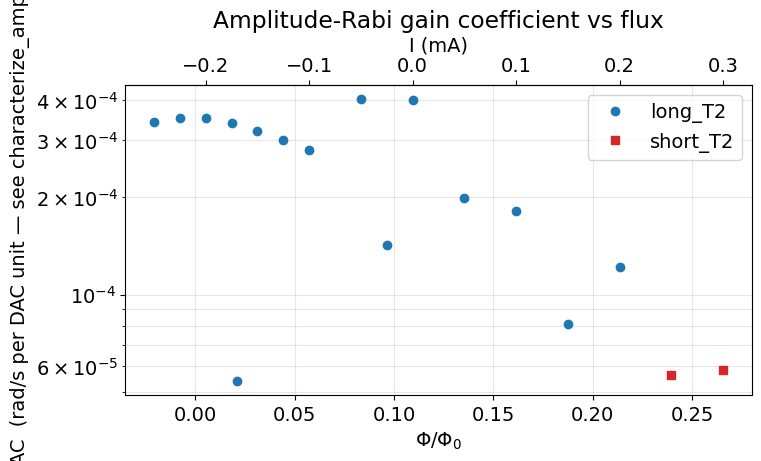

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5), constrained_layout=True)

for reg, marker, color in (('long_T2', 'o', 'tab:blue'), ('short_T2', 's', 'tab:red')):
    sel = char['regime'] == reg
    if not np.any(sel):
        continue
    ax.plot(I_to_phi(char['I_mA'][sel]), char['k_per_DAC'][sel], marker, color=color, label=reg)

ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('k_per_DAC  (rad/s per DAC unit — see characterize_amp_rabi)')
ax.set_yscale('log')
ax.set_title('Amplitude‐Rabi gain coefficient vs flux')
ax.legend(); ax.grid(alpha=0.3, which='both')
add_current_top_axis(ax)
plt.show()

## 3. Coupler T1 and T2 vs current

`T1` from `T1CouplerExperiment`. `T2` from Ramsey (long‐T2 regime) or spec‐vs‐power FWHM² vs A² intercept (short‐T2 regime) — markers distinguish.

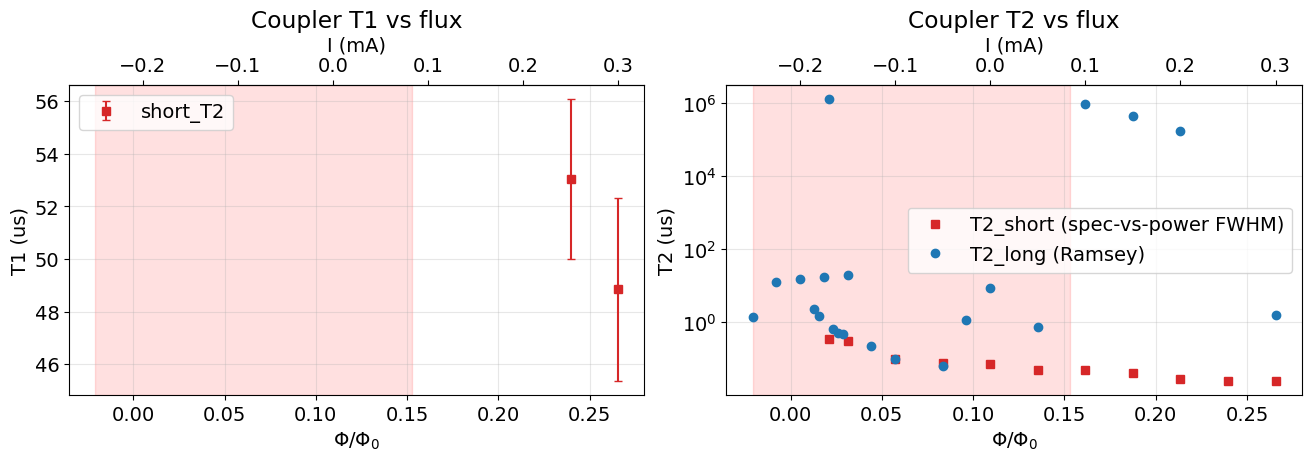

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

ax = axes[0]
for reg, marker, color in (('short_T2', 's', 'tab:red'),):
    sel = char['regime'] == reg
    if not np.any(sel):
        continue
    yerr = char['T1_err_us'][sel]
    yerr = np.where(np.isfinite(yerr), yerr, 0.0)
    ax.errorbar(I_to_phi(char['I_mA'][sel]), char['T1_us'][sel], yerr=yerr,
                fmt=marker, color=color, label=reg, capsize=3)
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('T1 (us)')
ax.set_title('Coupler T1 vs flux'); ax.legend(); ax.grid(alpha=0.3)
add_current_top_axis(ax)

ax = axes[1]
phi = I_to_phi(char['I_mA'])
for field, marker, color, label in (
    ('T2_short_us', 's', 'tab:red',  'T2_short (spec-vs-power FWHM)'),
    ('T2_long_us',  'o', 'tab:blue', 'T2_long (Ramsey)'),
):
    y = char[field]
    sel = np.isfinite(y)
    if not np.any(sel):
        continue
    ax.plot(phi[sel], y[sel], marker, color=color, label=label)
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('T2 (us)')
ax.set_yscale('log')
ax.set_title('Coupler T2 vs flux')
ax.legend(); ax.grid(alpha=0.3, which='both')
add_current_top_axis(ax)

plt.show()


In [24]:
# A_Phi at a single current from Ramsey T2 + |df/dPhi|, for both coupler and manipulate.
#   1/T_phi = 2*pi * |df/dPhi| * A_Phi * sqrt(2 * |ln(omega_ir * T2)|)
#   1/T_phi = 1/T2_Ramsey - 1/(2 T1)
# Requires: phi_dense, fm_d_grid, fc_d_grid (cell 12) and omega_ir, TAU_MEAS_S (section 5).

I_TARGET_MA = -0.05

# --- locate nearest characterization entry ---
char_dict = data['characterization']
key = min(char_dict.keys(), key=lambda k: abs(float(k) - I_TARGET_MA))
entry = char_dict[key]
I_used   = float(key)
phi_used = float(I_to_phi(I_used))

# --- measured times (us) ---
T1_c = (entry.get('T1') or {}).get('T1_us', np.nan)
T2_c = (entry.get('T2_long') or {}).get('T2_ramsey_us',
       entry.get('T2_long_us', np.nan))
man  = entry.get('manipulate') or {}
T1_m = man.get('T1_us', np.nan)
T2_m = man.get('T2_ramsey_us', np.nan)

# --- slopes at this flux (MHz / Phi0) from num-diag grids ---
dfc_dphi_grid = np.gradient(fc_d_grid, phi_dense)
dfm_dphi_grid = np.gradient(fm_d_grid, phi_dense)
dfc_dphi = float(np.interp(phi_used, phi_dense, dfc_dphi_grid))
dfm_dphi = float(np.interp(phi_used, phi_dense, dfm_dphi_grid))

def invert_A_phi(T2_us, T1_us, df_dphi_MHz_per_p0):
    """Return (A_Phi [Phi0], 1/T_phi [us^-1]) or (nan, ...) when invalid."""
    if not (np.isfinite(T2_us) and T2_us > 0):
        return np.nan, np.nan
    inv_Tphi = 1.0/T2_us
    if np.isfinite(T1_us) and T1_us > 0:
        inv_Tphi -= 0.5/T1_us
    if inv_Tphi <= 0:
        return np.nan, inv_Tphi
    L = np.sqrt(2.0 * abs(np.log(omega_ir * T2_us * 1e-6)))
    # inv_Tphi [us^-1] and df/dPhi [MHz/Phi0] share the 1e6 scale -> A_Phi in Phi0.
    A_phi = inv_Tphi / (2*np.pi * abs(df_dphi_MHz_per_p0) * L)
    return A_phi, inv_Tphi

A_c, inv_Tphi_c = invert_A_phi(T2_c, T1_c, dfc_dphi)
A_m, inv_Tphi_m = invert_A_phi(T2_m, T1_m, dfm_dphi)

print(f'Nearest current      : {I_used:+.4f} mA   (phi/phi0 = {phi_used:+.4f})')
print(f'Regime               : {entry.get("regime", "?")}')
print(f'tau_meas             : {TAU_MEAS_S:.0f} s   (omega_ir/2pi = {omega_ir/(2*np.pi):.2e} Hz)')
print()
print('COUPLER')
print(f'  T1                 : {T1_c:8.2f} us')
print(f'  T2_long (Ramsey)   : {T2_c:8.2f} us')
print(f'  1/T_phi            : {inv_Tphi_c*1e6:8.3e} Hz')
print(f'  |df_c/dPhi|        : {abs(dfc_dphi):8.2f} MHz/Phi0')
print(f'  A_Phi (coupler)    : {A_c*1e6:8.3f} uPhi0')
print()
print('MANIPULATE')
print(f'  T1                 : {T1_m:8.2f} us')
print(f'  T2 Ramsey          : {T2_m:8.2f} us')
print(f'  1/T_phi            : {inv_Tphi_m*1e6:8.3e} Hz')
print(f'  |df_m/dPhi|        : {abs(dfm_dphi):8.4f} MHz/Phi0')
print(f'  A_Phi (manipulate) : {A_m*1e6:8.3f} uPhi0')
print()
print(f'Ratio A_Phi^m / A_Phi^c = {A_m/A_c:.2f}   (should be ~1 if a single 1/f source dominates both)')


Nearest current      : -0.0500 mA   (phi/phi0 = +0.0833)
Regime               : long_T2
tau_meas             : 3600 s   (omega_ir/2pi = 2.78e-04 Hz)

COUPLER
  T1                 :    83.77 us
  T2_long (Ramsey)   :     0.06 us
  1/T_phi            : 1.565e+07 Hz
  |df_c/dPhi|        :  1280.70 MHz/Phi0
  A_Phi (coupler)    :  287.196 uPhi0

MANIPULATE
  T1                 :   161.63 us
  T2 Ramsey          :    83.90 us
  1/T_phi            : 8.825e+03 Hz
  |df_m/dPhi|        : 143.8367 MHz/Phi0
  A_Phi (manipulate) :    1.741 uPhi0

Ratio A_Phi^m / A_Phi^c = 0.01   (should be ~1 if a single 1/f source dominates both)


## 4. Manipulate T1 and T2 vs current

T1, T2 Ramsey and T2 Echo of the manipulate cavity, pulled from `e['manipulate']` in the lookup pickle.

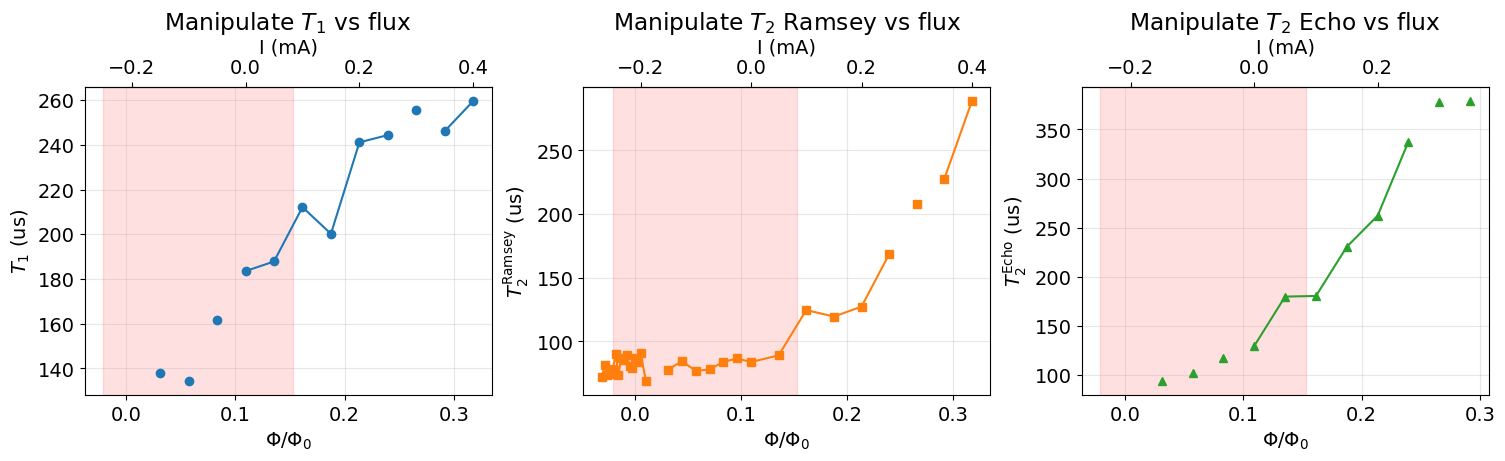

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

phi = I_to_phi(char['I_mA'])

ax = axes[0]
ax.plot(phi, char['T1_manipulate_us'], 'o-', color='tab:blue')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$T_1$ (us)')
ax.set_title('Manipulate $T_1$ vs flux'); ax.grid(alpha=0.3)
add_current_top_axis(ax)

ax = axes[1]
ax.plot(phi, char['T2_ramsey_manipulate_us'], 's-', color='tab:orange')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$T_2^{\mathrm{Ramsey}}$ (us)')
ax.set_title('Manipulate $T_2$ Ramsey vs flux'); ax.grid(alpha=0.3)
add_current_top_axis(ax)

ax = axes[2]
ax.plot(phi, char['T2_echo_manipulate_us'], '^-', color='tab:green')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$T_2^{\mathrm{Echo}}$ (us)')
ax.set_title('Manipulate $T_2$ Echo vs flux'); ax.grid(alpha=0.3)
add_current_top_axis(ax)

plt.show()


## 5. 1/f flux-noise check on manipulate $T_2^{\rm Ramsey}$

If the manipulate's pure dephasing is dominated by 1/f flux noise routed through the coupler:

$$ 1/T_\varphi \;=\; 2\pi\,\bigl|\partial f_m/\partial\Phi\bigr|\;A_\Phi\;\sqrt{2\,|\ln(\omega_{ir}\,t)|} $$

with $1/T_\varphi = 1/T_2^{\rm Ramsey} - 1/(2 T_1)$. We get $\partial f_m/\partial\Phi$ from the Lamb-shift model fit in section&nbsp;1 (numerical derivative of $f_m(\Phi) = \omega_m^{\rm bare} + g^2/(\omega_m^{\rm bare}-f_c(\Phi))$). Inverting the formula at each measured point gives an *implied* $A_\Phi$. If those values are roughly flat across $\Phi$, that's the 1/f-via-coupler signature; the absolute $A_\Phi$ is uncertain by a factor ~2 from the log-factor convention.

<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
C:\Users\26049\AppData\Local\Temp\ipykernel_9692\3160091777.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax.axhline(A_phi_med, color='k', ls=':', label=f'median = {A_phi_med:.2f} $\mu\Phi_0$')


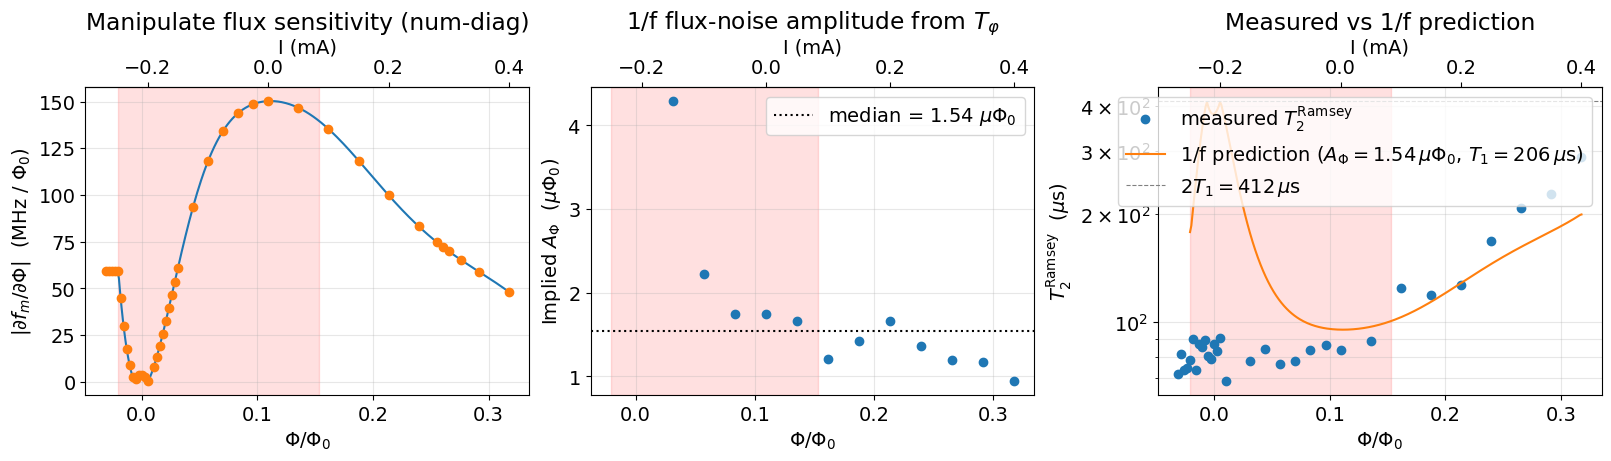

Median implied A_Phi = 1.541 uPhi0  (typical transmon: 1-10 uPhi0)
log factor used: sqrt(2 |ln(omega_ir * T2)|), tau_meas = 3600 s
Note: inside the shaded band the dressed |0,1> is hybridized with the coupler
      so the manipulate inherits coupler T1/T2 -- A_Phi inversion still works
      because we use the MEASURED T1, but the noise channel is no longer pure flux.

   Phi/Phi0   T2_R[us]    T1[us]     df/dPhi[MHz/Phi0]    A_Phi[uPhi0]
     -0.031       71.8       nan                 -59.5             nan
     -0.029       81.5       nan                 -59.5             nan
     -0.026       73.8       nan                 -59.5             nan
     -0.023       74.6       nan                 -59.5             nan
     -0.021       78.5       nan                 -59.5             nan
     -0.018       89.8       nan                 -44.9             nan
     -0.016       73.8       nan                 -29.7             nan
     -0.013       87.1       nan                 -17.7      

In [18]:
# Choice of coupler T2 source for section 6 (the manipulate analysis below
# always uses T2_ramsey_manipulate_us). Set to 'T2_long_us' (Ramsey) or
# 'T2_short_us' (spec-vs-power FWHM); falls back per-point automatically when
# the chosen field is NaN if COUPLER_T2_FALLBACK is True.
COUPLER_T2_FIELD = 'T2_short_us'   # 'T2_long_us' or 'T2_short_us'
COUPLER_T2_FALLBACK = False         # if True, fill NaNs from the other field

# 1/T_phi = 2*pi * |df_m/dPhi| * A_Phi * sqrt(2 * |ln(omega_ir * t)|)
# Convention: angular dw/dPhi = 2*pi*df/dPhi; A_Phi in Phi0; log factor approx sqrt(2 ln(tau_meas / t)).
# df_m/dPhi is now computed from the EXACT num-diag model (fm_d_grid in cell 12),
# not the analytical dispersive expansion -- valid through the avoided crossing.
TAU_MEAS_S = 3600.0                    # omega_ir = 2*pi / tau_meas (full experiment duration)
omega_ir = 2 * np.pi / TAU_MEAS_S

phi_meas = I_to_phi(char['I_mA'])

# Dense flux grid + num-diag manipulate frequency from cell 12
phi_dense = phi_grid_dense
fm_dense = fm_d_grid                              # MHz, dressed |0,1> energy
dfm_dphi_dense = np.gradient(fm_dense, phi_dense)  # MHz / Phi0
dfm_dphi_meas = np.interp(phi_meas, phi_dense, dfm_dphi_dense)

# Pure dephasing rate from T2_R minus T1 contribution
T1 = char['T1_manipulate_us']
T2R = char['T2_ramsey_manipulate_us']
inv_Tphi = 1.0 / T2R - 0.5 / T1                          # us^-1
with np.errstate(invalid='ignore'):
    inv_Tphi = np.where(inv_Tphi > 0, inv_Tphi, np.nan)

# Implied A_Phi at each measured point. Units cancel cleanly:
#   inv_Tphi [us^-1]  /  (2*pi * |df/dPhi| [MHz/Phi0]  *  L)  =  A_Phi [Phi0]
log_meas = np.sqrt(2.0 * np.abs(np.log(omega_ir * T2R * 1e-6)))
A_phi_Phi0 = inv_Tphi / (2 * np.pi * np.abs(dfm_dphi_meas) * log_meas)
A_phi_uPhi0 = A_phi_Phi0 * 1e6                           # uPhi0
A_phi_med = float(np.nanmedian(A_phi_uPhi0))

# Predicted T2_R(Phi) from a fixed A_Phi = median, with one iteration on the log factor
T1_med_us = float(np.nanmedian(T1))
def _predict_T2R(t0_s, A_Phi0):
    L = np.sqrt(2.0 * np.abs(np.log(omega_ir * t0_s)))
    inv_Tphi_Hz = 2 * np.pi * np.abs(dfm_dphi_dense) * 1e6 * A_Phi0 * L
    Tphi_us = 1e6 / inv_Tphi_Hz
    return 1.0 / (1.0/Tphi_us + 0.5/T1_med_us)
A_phi_fixed = A_phi_med * 1e-6
T2_pred = _predict_T2R(100e-6, A_phi_fixed)
T2_pred = _predict_T2R(np.nanmedian(T2_pred) * 1e-6, A_phi_fixed)  # 1 self-consistent iter

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(phi_dense, np.abs(dfm_dphi_dense), '-')
ax.plot(phi_meas, np.abs(dfm_dphi_meas), 'o')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$|\partial f_m/\partial\Phi|$  (MHz / $\Phi_0$)')
ax.set_title('Manipulate flux sensitivity (num-diag)')
ax.grid(alpha=0.3); add_current_top_axis(ax)

ax = axes[1]
ax.plot(phi_meas, A_phi_uPhi0, 'o')
ax.axhline(A_phi_med, color='k', ls=':', label=f'median = {A_phi_med:.2f} $\mu\Phi_0$')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'Implied $A_\Phi$  ($\mu\Phi_0$)')
ax.set_title(r'1/f flux-noise amplitude from $T_\varphi$')
ax.legend(); ax.grid(alpha=0.3); add_current_top_axis(ax)

ax = axes[2]
ax.plot(phi_meas, T2R, 'o', label=r'measured $T_2^{\rm Ramsey}$')
ax.plot(phi_dense, T2_pred, '-',
        label=fr'1/f prediction ($A_\Phi = {A_phi_med:.2f}\,\mu\Phi_0$, $T_1 = {T1_med_us:.0f}\,\mu$s)')
ax.axhline(2 * T1_med_us, color='gray', ls='--', lw=0.8, label=fr'$2 T_1 = {2*T1_med_us:.0f}\,\mu$s')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$T_2^{\rm Ramsey}$  ($\mu$s)')
ax.set_title('Measured vs 1/f prediction'); ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3, which='both'); add_current_top_axis(ax)

plt.show()

print(f'Median implied A_Phi = {A_phi_med:.3f} uPhi0  (typical transmon: 1-10 uPhi0)')
print(f'log factor used: sqrt(2 |ln(omega_ir * T2)|), tau_meas = {TAU_MEAS_S:.0f} s')
print(f'Note: inside the shaded band the dressed |0,1> is hybridized with the coupler')
print(f'      so the manipulate inherits coupler T1/T2 -- A_Phi inversion still works')
print(f'      because we use the MEASURED T1, but the noise channel is no longer pure flux.')
print()
print(f"  {'Phi/Phi0':>9}  {'T2_R[us]':>9}  {'T1[us]':>8}  {'df/dPhi[MHz/Phi0]':>20}  {'A_Phi[uPhi0]':>14}")
for phi_i, T2_i, T1_i, df_i, A_i in zip(phi_meas, T2R, T1, dfm_dphi_meas, A_phi_uPhi0):
    print(f'  {phi_i:+9.3f}  {T2_i:9.1f}  {T1_i:8.1f}  {df_i:+20.1f}  {A_i:14.2f}')


In [19]:
# --- Thermal-coupler dephasing on the manipulate (Gambetta/Sears) ---
# n_c jumps thermally; manipulate sees dispersive shift chi per photon.
# kappa = 1/T1_coupler (coupler T_phi does NOT enter -- pure dephasing
# randomizes coupler phase, not population).
#   Gamma_phi = (kappa/2) * Re[ sqrt((1 + i*chi/kappa)^2 + 4i*chi*n_th/kappa) - 1 ]
N_TH_LIST = (0.005, 0.02, 0.05)        # n_th values to overlay

# chi(phi) = E11 - E01 - E10 + E00  from num-diag (MHz, ordinary freq)
def _diag_chi_MHz(wc_bare):
    H_int = g_fit * (H_int_RWA + (H_int_CR if INCLUDE_CR else 0.0))
    H = (wc_bare * N_op_c + wm_bare_fit * N_op_m
         - 0.5 * ALPHA_FIXED_MHZ * H_duff + H_int)
    ev, ec = eigh(H)
    i00 = int(np.argmax(ec[bare_idx(0, 0), :]**2))
    i10 = int(np.argmax(ec[bare_idx(1, 0), :]**2))
    i01 = int(np.argmax(ec[bare_idx(0, 1), :]**2))
    i11 = int(np.argmax(ec[bare_idx(1, 1), :]**2))
    return ev[i11] - ev[i01] - ev[i10] + ev[i00]

wc_bare_dense = np.array([solve_wc_bare(fc, wm_bare_fit, g_fit) for fc in fc_d_grid])
chi_MHz_dense = np.array([_diag_chi_MHz(w) for w in wc_bare_dense])  # ordinary MHz

# kappa(phi): coupler 1/T1 interpolated to dense grid (us^-1)
T1c = char['T1_us']
ok_c = np.isfinite(T1c)
kappa_dense = 1.0 / np.interp(phi_dense, phi_meas[ok_c], T1c[ok_c])  # us^-1

# Sears formula: chi must be ANGULAR (rad/us = 2*pi * MHz). kappa already a rate.
chi_ang = 2 * np.pi * chi_MHz_dense
def _gamma_th(chi_ang_, kappa_, n_th):
    z = (1.0 + 1j * chi_ang_ / kappa_)**2 + 4j * chi_ang_ * n_th / kappa_
    return 0.5 * kappa_ * np.real(np.sqrt(z) - 1.0)               # us^-1

T2_th = {}
for n_th in N_TH_LIST:
    G = _gamma_th(chi_ang, kappa_dense, n_th)
    Tphi = np.where(G > 0, 1.0 / G, np.inf)
    T2_th[n_th] = 1.0 / (1.0 / Tphi + 0.5 / T1_med_us)            # us

print(f'\nThermal-coupler model:')
print(f'  |chi|/(2pi)  range: {np.nanmin(np.abs(chi_MHz_dense))*1e3:.1f} '
      f'to {np.nanmax(np.abs(chi_MHz_dense))*1e3:.1f} kHz '
      f'(median {np.nanmedian(np.abs(chi_MHz_dense))*1e3:.1f} kHz)')
print(f'  kappa/(2pi)  range: {np.nanmin(kappa_dense)/(2*np.pi)*1e3:.1f} '
      f'to {np.nanmax(kappa_dense)/(2*np.pi)*1e3:.1f} kHz')
print(f'  chi/kappa    range: {np.nanmin(np.abs(chi_ang)/kappa_dense):.2f} '
      f'to {np.nanmax(np.abs(chi_ang)/kappa_dense):.2f}  '
      f'(>>1 = strong-dispersive, T_phi -> T1_c/n_th)')



Thermal-coupler model:
  |chi|/(2pi)  range: 370.7 to 6824.8 kHz (median 2875.2 kHz)
  kappa/(2pi)  range: 1.6 to 3.6 kHz
  chi/kappa    range: 113.76 to 3858.68  (>>1 = strong-dispersive, T_phi -> T1_c/n_th)


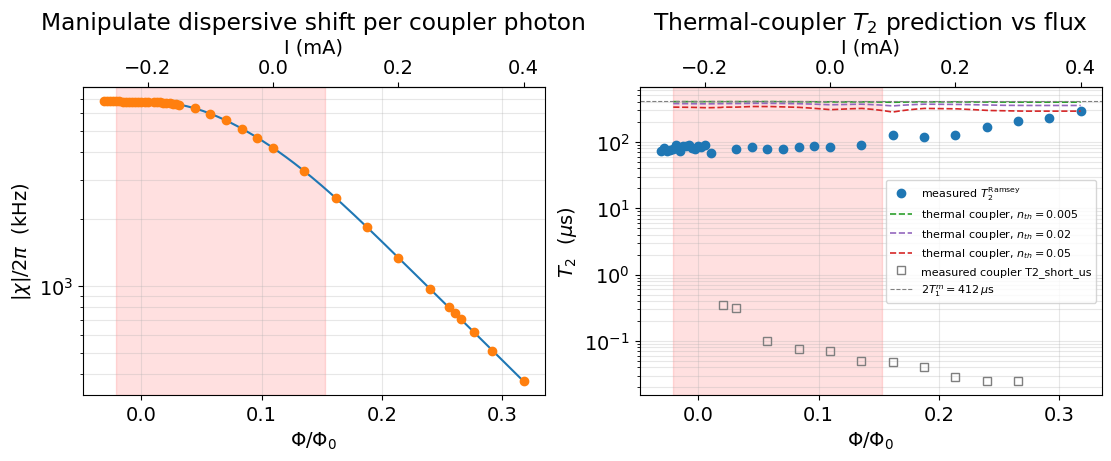

In [20]:
fig2, ax2 = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

# --- chi(phi) ---
ax = ax2[0]
ax.plot(phi_dense, np.abs(chi_MHz_dense) * 1e3, '-')
ax.plot(phi_meas, np.abs(np.interp(phi_meas, phi_dense, chi_MHz_dense)) * 1e3, 'o')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$')
ax.set_ylabel(r'$|\chi|/2\pi$  (kHz)')
ax.set_title('Manipulate dispersive shift per coupler photon')
ax.set_yscale('log'); ax.grid(alpha=0.3, which='both')
add_current_top_axis(ax)

# --- T2 from thermal-coupler model, several n_th ---
ax = ax2[1]
ax.plot(phi_meas, T2R, 'o', label=r'measured $T_2^{\rm Ramsey}$')
for n_th, c in zip(N_TH_LIST, ('tab:green', 'tab:purple', 'tab:red')):
    ax.plot(phi_dense, T2_th[n_th], '--', color=c, lw=1.2,
            label=fr'thermal coupler, $n_{{th}}={n_th:g}$')
ax.plot(phi_meas, char[COUPLER_T2_FIELD], 's', mfc='none', color='tab:gray',
        label=fr'measured coupler {COUPLER_T2_FIELD}')


ax.axhline(2 * T1_med_us, color='gray', ls='--', lw=0.8,
           label=fr'$2 T_1^m = {2*T1_med_us:.0f}\,\mu$s')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$')
ax.set_ylabel(r'$T_2$  ($\mu$s)')
ax.set_title('Thermal-coupler $T_2$ prediction vs flux')
ax.set_yscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
add_current_top_axis(ax)
plt.show()


## 6. Coupler vs manipulate: flux-noise comparison

If a single 1/f flux source dominates both qubits, the **coupler-derived** $A_\Phi^c$ should match the **manipulate-derived** $A_\Phi^m$. The coupler is the direct probe — its dephasing rate is set by its own bare flux sensitivity $\partial f_c/\partial\Phi$. The manipulate inherits flux sensitivity only through the dispersive Lamb shift, so $\partial f_m/\partial\Phi \approx (g/\Delta)^2 \cdot \partial f_c/\partial\Phi$ — much smaller, but coming from the *same* underlying $A_\Phi$ if the coupler is the noise channel.

We apply the same Ramsey-1/f inversion to the coupler's $T_2$. The coupler T2 source is controlled by **`COUPLER_T2_FIELD`** at the top of section&nbsp;5: set it to `'T2_long_us'` for the Ramsey envelope, or `'T2_short_us'` for the spec-vs-power FWHM. With `COUPLER_T2_FALLBACK = True`, NaNs in the chosen field are filled from the other field per-point.

**Caveats**

- In the `short_T2` regime, the spec-vs-power FWHM is a proxy for $T_2$, so $A_\Phi^c$ from that field is good only to ~$O(1)$. Prefer `T2_long_us` (Ramsey) where it exists.
- Inside the dispersive-breakdown band (red), $A_\Phi^m$ is unreliable — disagreement there should not be over-interpreted.
- Both estimates use the same log-factor convention; the *ratio* is the cleanest diagnostic since common factors cancel.


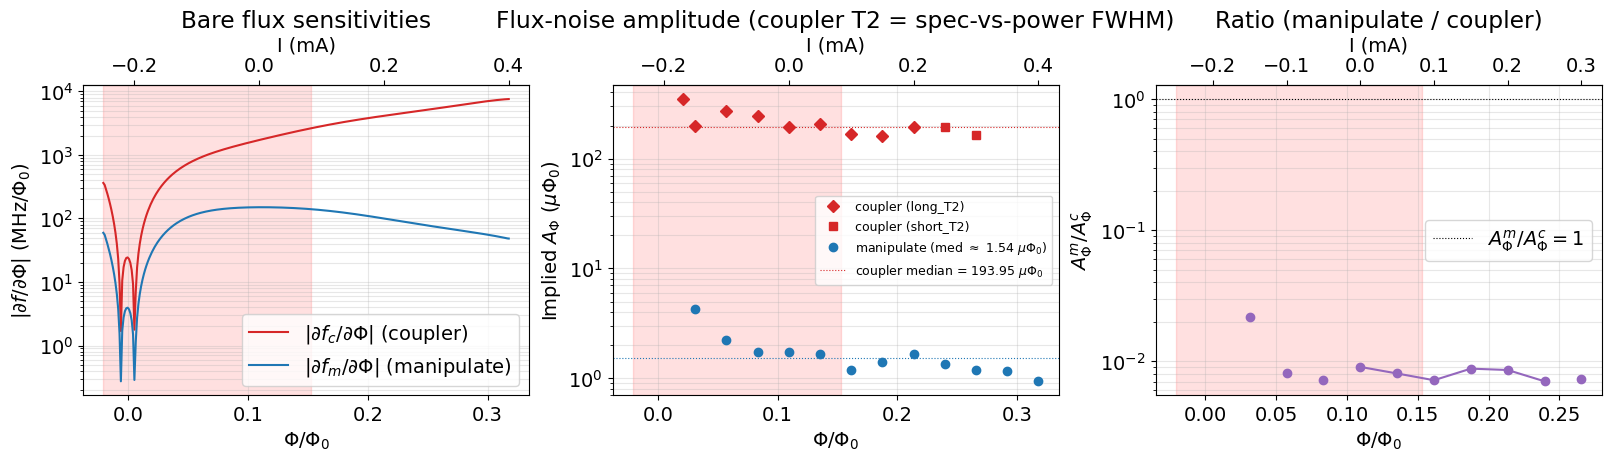

Coupler T2 source: T2_short_us
Median A_Phi (coupler):    193.949 uPhi0
Median A_Phi (manipulate): 1.541 uPhi0
Median ratio (m / c):      0.008   (1.0 = same noise source)

   Phi/Phi0     regime       T2_src   T2_c[us]   T1_c[us]     df_c/dPhi[MHz/Phi0]    A_Phi_c[uPhi0]    A_Phi_m[uPhi0]    ratio
     -0.031          ?  T2_short_us        nan        nan                  -362.2               nan               nan      nan
     -0.029          ?  T2_short_us        nan        nan                  -362.2               nan               nan      nan
     -0.026          ?  T2_short_us        nan        nan                  -362.2               nan               nan      nan
     -0.023          ?  T2_short_us        nan        nan                  -362.2               nan               nan      nan
     -0.021    long_T2  T2_short_us        nan      86.77                  -362.2               nan               nan      nan
     -0.018          ?  T2_short_us        nan        nan        

In [21]:
# Section 6: same Ramsey-1/f inversion applied to the coupler.
# Reuses phi_dense (= phi_grid_dense), omega_ir, dfm_dphi_dense, A_phi_uPhi0,
# A_phi_med from section 5; df_c/dPhi comes from the cached fc_d_grid.
# Coupler T2 source is selected by COUPLER_T2_FIELD set in section 5.

# Coupler dressed flux sensitivity from the cached num-diag grid
dfc_dphi_dense = np.gradient(fc_d_grid, phi_dense)               # MHz / Phi0
dfc_dphi_meas = np.interp(phi_meas, phi_dense, dfc_dphi_dense)

# Coupler T1 and T2 -- chosen by COUPLER_T2_FIELD (see section 5)
T1_c = char['T1_us']
T2_c = np.array(char[COUPLER_T2_FIELD], dtype=float)
T2_c_label = {'T2_long_us': 'Ramsey', 'T2_short_us': 'spec-vs-power FWHM'}.get(
    COUPLER_T2_FIELD, COUPLER_T2_FIELD)
if COUPLER_T2_FALLBACK:
    other = 'T2_short_us' if COUPLER_T2_FIELD == 'T2_long_us' else 'T2_long_us'
    T2_c = np.where(np.isfinite(T2_c), T2_c, np.array(char[other], dtype=float))
T2_c_source = np.where(np.isfinite(np.array(char[COUPLER_T2_FIELD], dtype=float)),
                       COUPLER_T2_FIELD,
                       ('T2_short_us' if COUPLER_T2_FIELD == 'T2_long_us' else 'T2_long_us')
                       if COUPLER_T2_FALLBACK else COUPLER_T2_FIELD)
regime = char['regime']
inv_Tphi_c = 1.0/T2_c - 0.5/T1_c                                  # us^-1
with np.errstate(invalid='ignore'):
    inv_Tphi_c = np.where(inv_Tphi_c > 0, inv_Tphi_c, np.nan)

log_meas_c = np.sqrt(2.0 * np.abs(np.log(omega_ir * T2_c * 1e-6)))
A_phi_c_Phi0 = inv_Tphi_c / (2 * np.pi * np.abs(dfc_dphi_meas) * log_meas_c)
A_phi_c_uPhi0 = A_phi_c_Phi0 * 1e6
A_phi_c_med = float(np.nanmedian(A_phi_c_uPhi0))

# Ratio (manipulate / coupler) -- should be O(1) if same flux noise drives both
ratio = A_phi_uPhi0 / A_phi_c_uPhi0

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(phi_dense, np.abs(dfc_dphi_dense), '-', color='tab:red',  label=r'$|\partial f_c/\partial\Phi|$ (coupler)')
ax.plot(phi_dense, np.abs(dfm_dphi_dense), '-', color='tab:blue', label=r'$|\partial f_m/\partial\Phi|$ (manipulate)')
ax.set_yscale('log')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$|\partial f/\partial\Phi|$ (MHz/$\Phi_0$)')
ax.set_title('Bare flux sensitivities')
ax.legend(); ax.grid(alpha=0.3, which='both'); add_current_top_axis(ax)

ax = axes[1]
# Mark coupler regime via marker shape
for reg, marker in (('long_T2', 'D'), ('short_T2', 's')):
    sel = regime == reg
    if not np.any(sel):
        continue
    ax.plot(phi_meas[sel], A_phi_c_uPhi0[sel], marker, color='tab:red',
            label=fr'coupler ({reg})')
ax.plot(phi_meas, A_phi_uPhi0, 'o', color='tab:blue',
        label=fr'manipulate (med $\approx$ {A_phi_med:.2f} $\mu\Phi_0$)')
ax.axhline(A_phi_c_med, color='tab:red',  ls=':', lw=0.8, label=fr'coupler median = {A_phi_c_med:.2f} $\mu\Phi_0$')
ax.axhline(A_phi_med,   color='tab:blue', ls=':', lw=0.8)
ax.set_yscale('log')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'Implied $A_\Phi$ ($\mu\Phi_0$)')
ax.set_title(f'Flux-noise amplitude (coupler T2 = {T2_c_label})')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both'); add_current_top_axis(ax)

ax = axes[2]
ax.plot(phi_meas, ratio, 'o-', color='tab:purple')
ax.axhline(1, color='k', ls=':', lw=0.8, label=r'$A_\Phi^m / A_\Phi^c = 1$')
ax.set_yscale('log')
shade_hybrid(ax, label='_nolegend_')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$A_\Phi^m / A_\Phi^c$')
ax.set_title('Ratio (manipulate / coupler)')
ax.legend(); ax.grid(alpha=0.3, which='both'); add_current_top_axis(ax)

plt.show()

print(f'Coupler T2 source: {COUPLER_T2_FIELD}'
      + (f' (with fallback to other when NaN)' if COUPLER_T2_FALLBACK else ''))
print(f'Median A_Phi (coupler):    {A_phi_c_med:.3f} uPhi0')
print(f'Median A_Phi (manipulate): {A_phi_med:.3f} uPhi0')
print(f'Median ratio (m / c):      {float(np.nanmedian(ratio)):.3f}   (1.0 = same noise source)')
print()
hdr = f'  {"Phi/Phi0":>9}  {"regime":>9}  {"T2_src":>11}  {"T2_c[us]":>9}  {"T1_c[us]":>9}  {"df_c/dPhi[MHz/Phi0]":>22}  {"A_Phi_c[uPhi0]":>16}  {"A_Phi_m[uPhi0]":>16}  {"ratio":>7}'
print(hdr)
for phi_i, reg_i, src_i, T2c_i, T1c_i, dfc_i, Ac_i, Am_i, r_i in zip(
        phi_meas, regime, T2_c_source, T2_c, T1_c, dfc_dphi_meas, A_phi_c_uPhi0, A_phi_uPhi0, ratio):
    print(f'  {phi_i:+9.3f}  {reg_i:>9}  {src_i:>11}  {T2c_i:9.4f}  {T1c_i:9.2f}  {dfc_i:+22.1f}  {Ac_i:16.2f}  {Am_i:16.2f}  {r_i:7.3f}')


## 7. 1/f vs white noise — coupler lineshape diagnostics

Two CW signatures of inhomogeneous (1/f) vs homogeneous (white) noise:

1. **Power-broadening stiffness.** White noise gives `FWHM(P) ≈ 2Γ + b·√P` (slope nonzero at low P). 1/f gives a Gaussian envelope `F_G` that the Lorentzian core has to saturate before FWHM grows — flat then knee. We fit `FWHM(g) = √(F_G² + (c·g)²)` and a linear `FWHM = a + b·g`, compare χ².

2. **Tail residuals.** Lorentzian tails decay as `1/Δ²`; Gaussian tails as `exp(-Δ²)`. A pure-Lorentzian fit to a Gaussian peak leaves a "W"-shaped residual. We fit both to the lowest-gain row.

Cross-check: if 1/f flux noise dominates, `F_G ∝ |∂f_c/∂Φ|` across the swept currents. Slope of that relation gives an independent estimate of `A_Φ` (CW-derived, no T2 inversion).

### Single-bias diagnostic (pick `I_DIAG_mA`)

I = -0.1700 mA
  power-broadening fits:
    linear      FWHM = 0.707 + 4.566e-03*gain   chi² = 0.040
    quadrature  F_G = 0.846 MHz, c = 7.217e-03     chi² = 0.097
    -> white-favored (linear better)
  lineshape (lowest-gain row, gain=5):
    chi²_Lor   = 5.502e+03
    chi²_Gauss = 5.501e+03
    -> Gaussian wins (1/f signature)
    Gaussian sigma = 0.345 MHz, FWHM_G = 0.812 MHz


C:\Users\26049\AppData\Local\Temp\ipykernel_9692\4155446582.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9); ax.grid(alpha=0.3)


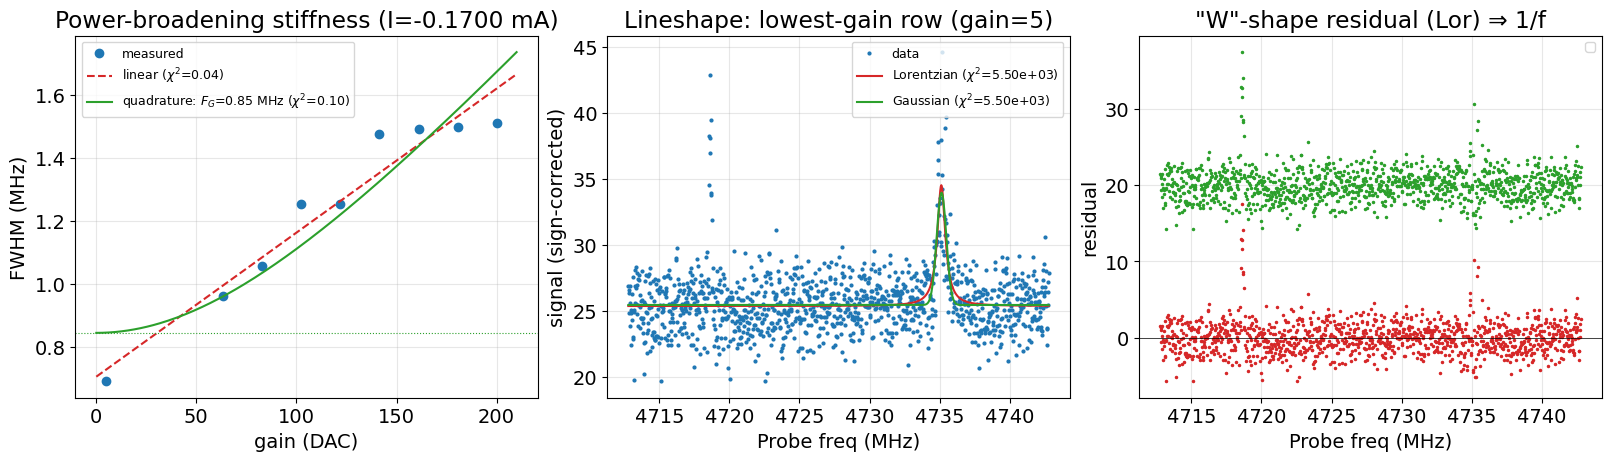

In [22]:
import scipy.optimize as opt

I_DIAG_mA = -0.17       # bias to diagnose (use a clean spec_vs_power entry)

char_dict = data.get('characterization', {})
key_DIAG = min(char_dict.keys(), key=lambda kk: abs(float(kk) - I_DIAG_mA))
entry = char_dict[key_DIAG]
sp = entry.get('spec_vs_power')
if sp is None:
    raise ValueError(f'No spec_vs_power data at I={key_DIAG} mA')


pt_to_delete = [1, 2]  # indices of points to delete from the fits (e.g. outliers, points inside the hybridized regime)

gains_diag   = np.asarray(sp['gains'],   dtype=float)
fwhms_diag   = np.asarray(sp['FWHMs'],   dtype=float)
xpts_2d_diag = np.asarray(sp['xpts_2d'], dtype=float)
sig_2d_diag  = np.asarray(sp['signal_2d'], dtype=float)
finite = np.isfinite(gains_diag) & np.isfinite(fwhms_diag)

# Remove any bad points from the fits (but keep them in the plot)
finite[pt_to_delete] = False



# --- Fit 1: linear FWHM = a + b*g ---
def lin_model(g, a, b):
    return a + b * g
p_lin, _ = opt.curve_fit(lin_model, gains_diag[finite], fwhms_diag[finite],
                          p0=[fwhms_diag[finite].min(), 1e-4])
a_lin, b_lin = p_lin
chi2_lin = float(np.sum((fwhms_diag[finite] - lin_model(gains_diag[finite], *p_lin))**2))

# --- Fit 2: quadrature FWHM = sqrt(F_G^2 + (c*g)^2) ---
def quad_model(g, F_G, c):
    return np.sqrt(F_G**2 + (c * g)**2)
p_quad, _ = opt.curve_fit(quad_model, gains_diag[finite], fwhms_diag[finite],
                           p0=[fwhms_diag[finite].min(), 1e-4],
                           bounds=([0, 0], [np.inf, np.inf]))
F_G, c_pb = p_quad
chi2_quad = float(np.sum((fwhms_diag[finite] - quad_model(gains_diag[finite], *p_quad))**2))

# --- Lineshape on lowest-gain row ---
def lor_pdf(x, A, x0, gamma, y0):
    return y0 + A * gamma**2 / ((x - x0)**2 + gamma**2)
def gauss_pdf(x, A, x0, sigma, y0):
    return y0 + A * np.exp(-((x - x0)**2) / (2 * sigma**2))

i_low = int(np.nanargmin(gains_diag))
xrow = xpts_2d_diag[i_low]
yrow = sig_2d_diag[i_low]
med = float(np.median(yrow))
sign = 1 if (np.max(yrow) - med) >= (med - np.min(yrow)) else -1
y_signed = sign * yrow
A0 = float(np.max(y_signed - np.median(y_signed)))
x00 = float(xrow[int(np.argmax(y_signed - np.median(y_signed)))])
g0 = max(2.0, (xrow[-1] - xrow[0]) / 30.0)

p_lor, _ = opt.curve_fit(lor_pdf,   xrow, y_signed, p0=[A0, x00, g0, float(np.median(y_signed))], maxfev=8000)
p_gau, _ = opt.curve_fit(gauss_pdf, xrow, y_signed, p0=[A0, x00, g0, float(np.median(y_signed))], maxfev=8000)
res_lor = y_signed - lor_pdf(xrow,   *p_lor)
res_gau = y_signed - gauss_pdf(xrow, *p_gau)
chi2_lor = float(np.sum(res_lor**2))
chi2_gau = float(np.sum(res_gau**2))

print(f'I = {key_DIAG:+.4f} mA')
print(f'  power-broadening fits:')
print(f'    linear      FWHM = {a_lin:.3f} + {b_lin:.3e}*gain   chi² = {chi2_lin:.3f}')
print(f'    quadrature  F_G = {F_G:.3f} MHz, c = {c_pb:.3e}     chi² = {chi2_quad:.3f}')
print(f'    -> {"1/f-favored (quadrature better)" if chi2_quad < chi2_lin else "white-favored (linear better)"}')
print(f'  lineshape (lowest-gain row, gain={gains_diag[i_low]:.0f}):')
print(f'    chi²_Lor   = {chi2_lor:.3e}')
print(f'    chi²_Gauss = {chi2_gau:.3e}')
print(f'    -> {"Gaussian wins (1/f signature)" if chi2_gau < chi2_lor else "Lorentzian wins (white noise)"}')
print(f'    Gaussian sigma = {abs(p_gau[2]):.3f} MHz, FWHM_G = {2.355*abs(p_gau[2]):.3f} MHz')

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

ax = axes[0]
g_dense_plot = np.linspace(0, gains_diag[finite].max() * 1.05, 200)
ax.plot(gains_diag[finite], fwhms_diag[finite], 'o', label='measured')
ax.plot(g_dense_plot, lin_model(g_dense_plot, *p_lin), '--', color='tab:red',
        label=f'linear ($\\chi^2$={chi2_lin:.2f})')
ax.plot(g_dense_plot, quad_model(g_dense_plot, *p_quad), '-', color='tab:green',
        label=fr'quadrature: $F_G$={F_G:.2f} MHz ($\chi^2$={chi2_quad:.2f})')
ax.axhline(F_G, color='tab:green', ls=':', lw=0.8)
ax.set_xlabel('gain (DAC)'); ax.set_ylabel('FWHM (MHz)')
ax.set_title(f'Power-broadening stiffness (I={key_DIAG:+.4f} mA)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(xrow, y_signed, '.', ms=4, label='data')
xrow_dense = np.linspace(xrow[0], xrow[-1], 800)
ax.plot(xrow_dense, lor_pdf(xrow_dense,   *p_lor), '-', color='tab:red',
        label=f'Lorentzian ($\\chi^2$={chi2_lor:.2e})')
ax.plot(xrow_dense, gauss_pdf(xrow_dense, *p_gau), '-', color='tab:green',
        label=f'Gaussian ($\\chi^2$={chi2_gau:.2e})')
ax.set_xlabel('Probe freq (MHz)'); ax.set_ylabel('signal (sign-corrected)')
ax.set_title(f'Lineshape: lowest-gain row (gain={gains_diag[i_low]:.0f})')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[2]

# Optional: faint raw points underneath, bold smoothed line on top
ax.plot(xrow, res_lor, '.', ms=3, color='tab:red',   alpha=1)
ax.plot(xrow, res_gau + 20, '.', ms=3, color='tab:green', alpha=1)

ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Probe freq (MHz)'); ax.set_ylabel('residual')
ax.set_title('"W"-shape residual (Lor) ⇒ 1/f')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.show()


In [15]:
# --- T2 estimates from each noise model ---
# White noise (Lorentzian):  FWHM_L = 1/(pi * T2)         => T2[us] = 1 / (pi * FWHM[MHz])
# 1/f noise (Gaussian):      sigma_f = 1/(2pi * T2*)      => T2[us] = 1 / (2pi * sigma_f[MHz])
#                            FWHM_G = 2*sqrt(2 ln 2) * sigma_f ~ 2.355 * sigma_f

# White-noise reads
T2_white_pb = 1.0 / (np.pi * a_lin) if a_lin > 0 else float('nan')        # from linear-fit intercept
FWHM_L_ls   = 2.0 * abs(p_lor[2])                                          # gamma is HWHM
T2_white_ls = 1.0 / (np.pi * FWHM_L_ls) if FWHM_L_ls > 0 else float('nan') # from Lorentzian lineshape

# 1/f reads (CW: F_G is the static Gaussian width, no log factor like in time-domain)
sigma_G_pb  = F_G / 2.355
T2_1f_pb    = 1.0 / (2.0 * np.pi * sigma_G_pb) if sigma_G_pb > 0 else float('nan')
sigma_G_ls  = abs(p_gau[2])
FWHM_G_ls   = 2.355 * sigma_G_ls
T2_1f_ls    = 1.0 / (2.0 * np.pi * sigma_G_ls) if sigma_G_ls > 0 else float('nan')

print(f'  T2 estimates [us]:')
print(f'    white noise  (FWHM_L = 1/(pi T2)):')
print(f'      from linear power-broadening intercept (a={a_lin:.3f} MHz)  -> T2 = {T2_white_pb:.3f}')
print(f'      from Lorentzian lineshape (FWHM_L={FWHM_L_ls:.3f} MHz)      -> T2 = {T2_white_ls:.3f}')
print(f'    1/f noise    (sigma_f = 1/(2 pi T2*)):')
print(f'      from quadrature F_G ({F_G:.3f} MHz)                          -> T2* = {T2_1f_pb:.3f}')
print(f'      from Gaussian lineshape sigma_G ({sigma_G_ls:.3f} MHz, FWHM_G={FWHM_G_ls:.3f} MHz) -> T2* = {T2_1f_ls:.3f}')


  T2 estimates [us]:
    white noise  (FWHM_L = 1/(pi T2)):
      from linear power-broadening intercept (a=0.707 MHz)  -> T2 = 0.450
      from Lorentzian lineshape (FWHM_L=0.692 MHz)      -> T2 = 0.460
    1/f noise    (sigma_f = 1/(2 pi T2*)):
      from quadrature F_G (0.846 MHz)                          -> T2* = 0.443
      from Gaussian lineshape sigma_G (0.345 MHz, FWHM_G=0.812 MHz) -> T2* = 0.462


I = -0.1700 mA   (T1 used = 86.27 us)
  two-pass per-row Lorentzian: 11 rows, pre-sat = 8, inliers (MAD+manual) = 9
  FWHM^2 = b + m*A^2:  b = 0.847 MHz^2, m = 4.5e-05
      T2 (intercept) = 0.35 us
      k_per_DAC      = 1.335e-03
      F_G = sqrt(b)  = 0.921 MHz
  power-broadening chi² on inliers:
    linear      chi² = 0.040
    quadrature  chi² = 0.110
    -> white-favored (linear better)
  lineshape (gain=5, lowest inlier):
    chi²_Lor   = 5.502e+03
    chi²_Gauss = 5.501e+03
    -> Gaussian wins (1/f signature)
    Gaussian sigma = 0.345 MHz, FWHM_G = 0.812 MHz


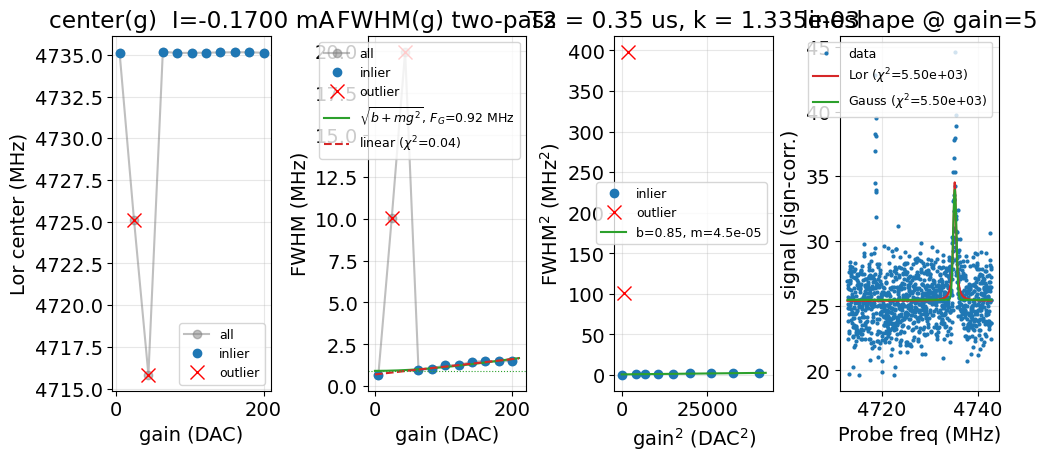


WRITE_BACK: refreshed two-pass fit fields in data["characterization"][-0.17]["spec_vs_power"]
             -> entry["T2_short_us"] = 0.35 us  (pick = spec_T2+rabi_k)
PERSIST_TO_DISK: re-pickled to D:\experiments\260420_T2_AC_stark\data\coupler_lookup_tables.pkl


In [16]:
import scipy.optimize as opt
import pickle
import fitting.fitting as _fitter

# ---------------- knobs ----------------
I_DIAG_mA          = -0.17       # bias to diagnose
EXTRA_DROP         = [1,2]          # gain-row indices to force-drop (on top of MAD rejection)
SIGN               = 'auto'      # 'auto', +1, or -1
SAT_FRAC           = 0.90        # saturation threshold (fraction of max amplitude)
OUTLIER_THRESH_MAD = 3.0         # MAD threshold for FWHM^2-vs-A^2 outlier rejection
T1_US_OVERRIDE     = None        # None -> entry['T1']['T1_us']
WRITE_BACK         = True       # True -> overwrite per-row fit fields in sp
PERSIST_TO_DISK    = True       # True -> re-pickle data to LOOKUP_PATH (needs WRITE_BACK)


# ---------------- helpers (mirrored from coupler_systematic_study) ----------------
def _fit_lorentzian_row(freqs, signal, *, sign='auto', fitparams=None):
    freqs = np.asarray(freqs, dtype=float); signal = np.asarray(signal, dtype=float)
    if sign == 'auto':
        sign_used = -1 if (signal.max() - signal.mean()) < (signal.mean() - signal.min()) else 1
    else:
        sign_used = int(sign)
    popt, _ = _fitter.fitlor(freqs, sign_used * signal, fitparams=fitparams)
    return np.asarray(popt, dtype=float), int(sign_used)

def _mad_outlier_mask(values, *, thresh=3.0):
    if thresh is None: return np.ones_like(values, dtype=bool)
    v = np.asarray(values, dtype=float)
    med = np.nanmedian(v); mad = np.nanmedian(np.abs(v - med))
    if mad <= 0 or not np.isfinite(mad): return np.ones_like(v, dtype=bool)
    return np.abs(v - med) <= thresh * 1.4826 * mad

def _linearize_fwhm_vs_gain(gains, fwhms, T1_us, *, outlier_thresh_mad=3.0,
                            extra_drop_mask=None):
    gains = np.asarray(gains, dtype=float); fwhms = np.asarray(fwhms, dtype=float)
    finite = np.isfinite(fwhms) & (gains > 0)
    if extra_drop_mask is not None:
        finite &= ~np.asarray(extra_drop_mask, dtype=bool)
    A2 = gains[finite]**2; y = fwhms[finite]**2
    inlier_full = np.zeros_like(gains, dtype=bool)
    nan_out = dict(T2_us=float('nan'), k_per_DAC=float('nan'),
                   FWHM_intercept=float('nan'), FWHM_slope=float('nan'),
                   inlier_mask=inlier_full, residuals=np.full_like(gains, np.nan))
    if A2.size < 3: return nan_out
    m0, b0 = np.polyfit(A2, y, 1)
    inlier = _mad_outlier_mask(y - (m0*A2 + b0), thresh=outlier_thresh_mad)
    if inlier.sum() < 3: inlier = np.ones_like(y, dtype=bool)
    m, b = np.polyfit(A2[inlier], y[inlier], 1)
    if not (np.isfinite(b) and b > 0): return nan_out
    T2 = 1.0 / (np.pi * np.sqrt(b))
    if T1_us is not None and np.isfinite(T1_us) and T1_us > 0 and m > 0:
        k = float(np.sqrt(np.pi / T1_us) * np.sqrt(m) * b**(-0.25))
    else:
        k = float('nan')
    inlier_full[finite] = inlier
    res_full = np.full_like(gains, np.nan); res_full[finite] = y - (m*A2 + b)
    return dict(T2_us=float(T2), k_per_DAC=k,
                FWHM_intercept=float(b), FWHM_slope=float(m),
                inlier_mask=inlier_full, residuals=res_full)


# ---------------- pick entry ----------------
char_dict = data.get('characterization', {})
key_DIAG  = min(char_dict.keys(), key=lambda kk: abs(float(kk) - I_DIAG_mA))
entry     = char_dict[key_DIAG]
sp        = entry.get('spec_vs_power')
if sp is None:
    raise ValueError(f'No spec_vs_power data at I={key_DIAG} mA')

T1_us = T1_US_OVERRIDE if T1_US_OVERRIDE is not None \
        else float(entry.get('T1', {}).get('T1_us', np.nan))

gains_diag   = np.asarray(sp['gains'],     dtype=float)
xpts_2d_diag = np.asarray(sp['xpts_2d'],   dtype=float)
sig_2d_diag  = np.asarray(sp['signal_2d'], dtype=float)
n_rows       = len(gains_diag)


# ---------------- pass 1: independent per-row Lorentzian ----------------
fwhms      = np.full(n_rows, np.nan)
centers    = np.full(n_rows, np.nan)
amps       = np.full(n_rows, np.nan)
lor_params = [None] * n_rows
signs      = [0] * n_rows

for i in range(n_rows):
    try:
        popt, s_used  = _fit_lorentzian_row(xpts_2d_diag[i], sig_2d_diag[i], sign=SIGN)
        lor_params[i] = popt; signs[i] = s_used
        centers[i] = float(popt[2]); fwhms[i] = 2*abs(float(popt[3])); amps[i] = float(popt[1])
    except Exception as e:
        print(f'pass1 fit failed @ gain={gains_diag[i]:.0f}: {type(e).__name__}: {e}')


# ---------------- saturation detection ----------------
amax = np.nanmax(amps) if np.any(np.isfinite(amps)) else 0.0
if np.isfinite(amax) and amax > 0:
    sat_mask = amps >= (SAT_FRAC * amax)
    pre_idx  = np.arange(int(np.where(sat_mask)[0][0])) if sat_mask.any() else np.arange(n_rows)
    if pre_idx.size == 0: pre_idx = np.arange(n_rows)
else:
    pre_idx = np.arange(n_rows)

valid     = np.array([p is not None for p in lor_params])
pre_valid = np.intersect1d(pre_idx, np.where(valid)[0])


# ---------------- pass 2: re-fit pre-saturation rows with mean-based init ----------------
if pre_valid.size > 0:
    init = [float(np.nanmean([lor_params[i][0]      for i in pre_valid])),
            float(np.nanmean([lor_params[i][1]      for i in pre_valid])),
            float(np.nanmean([lor_params[i][2]      for i in pre_valid])),
            float(np.nanmean([abs(lor_params[i][3]) for i in pre_valid]))]
else:
    init = [float(np.nanmedian(sig_2d_diag)),
            float(np.nanmax(sig_2d_diag) - np.nanmin(sig_2d_diag)),
            float(np.nanmean(xpts_2d_diag)),
            (float(np.nanmax(xpts_2d_diag)) - float(np.nanmin(xpts_2d_diag))) / 10.0]

for i in pre_idx:
    try:
        popt, _ = _fitter.fitlor(xpts_2d_diag[i],
                                 (signs[i] if signs[i] else 1) * sig_2d_diag[i],
                                 fitparams=init)
        lor_params[i] = np.asarray(popt, dtype=float)
        centers[i] = float(popt[2]); fwhms[i] = 2*abs(float(popt[3])); amps[i] = float(popt[1])
        signs[i]   = int(signs[i] or 1)
    except Exception:
        pass


# ---------------- linearization (FWHM^2 = b + m*A^2) with MAD + manual drops ----------------
extra_drop_mask = np.zeros(n_rows, dtype=bool)
if EXTRA_DROP: extra_drop_mask[EXTRA_DROP] = True
lin = _linearize_fwhm_vs_gain(gains_diag, fwhms, T1_us,
                              outlier_thresh_mad=OUTLIER_THRESH_MAD,
                              extra_drop_mask=extra_drop_mask)
b_int, m_slope   = lin['FWHM_intercept'], lin['FWHM_slope']
T2_us, k_per_DAC = lin['T2_us'], lin['k_per_DAC']
inlier = np.asarray(lin['inlier_mask'], dtype=bool) & ~extra_drop_mask


# ---------------- noise-color: linear (white) vs quadrature (1/f), and Lor vs Gauss on lowest inlier ----------------
def lin_model(g, a, b): return a + b*g
chi2_lin = chi2_quad = float('nan')
if inlier.sum() >= 2:
    p_lin, _  = opt.curve_fit(lin_model, gains_diag[inlier], fwhms[inlier],
                              p0=[fwhms[inlier].min(), 1e-4])
    chi2_lin  = float(np.sum((fwhms[inlier] - lin_model(gains_diag[inlier], *p_lin))**2))
    quad_pred = np.sqrt(np.maximum(b_int + m_slope * gains_diag[inlier]**2, 0.0))
    chi2_quad = float(np.sum((fwhms[inlier] - quad_pred)**2))

def lor_pdf(x, A, x0, gamma, y0): return y0 + A * gamma**2 / ((x - x0)**2 + gamma**2)
def gauss_pdf(x, A, x0, sigma, y0): return y0 + A * np.exp(-((x - x0)**2) / (2 * sigma**2))

inlier_idx = np.where(inlier & valid)[0]
i_low = int(inlier_idx[np.argmin(gains_diag[inlier_idx])]) if inlier_idx.size else int(np.nanargmin(gains_diag))
xrow, yrow = xpts_2d_diag[i_low], sig_2d_diag[i_low]
sign_low   = signs[i_low] if signs[i_low] else 1
y_signed   = sign_low * yrow
A0  = float(np.max(y_signed - np.median(y_signed)))
x00 = float(xrow[int(np.argmax(y_signed - np.median(y_signed)))])
g0  = max(2.0, (xrow[-1] - xrow[0]) / 30.0)

p_lor, _ = opt.curve_fit(lor_pdf,   xrow, y_signed, p0=[A0, x00, g0, float(np.median(y_signed))], maxfev=8000)
p_gau, _ = opt.curve_fit(gauss_pdf, xrow, y_signed, p0=[A0, x00, g0, float(np.median(y_signed))], maxfev=8000)
chi2_lor = float(np.sum((y_signed - lor_pdf(xrow,   *p_lor))**2))
chi2_gau = float(np.sum((y_signed - gauss_pdf(xrow, *p_gau))**2))


# ---------------- summary print ----------------
print(f'I = {key_DIAG:+.4f} mA   (T1 used = {T1_us:.2f} us)')
print(f'  two-pass per-row Lorentzian: {n_rows} rows, pre-sat = {pre_idx.size}, '
      f'inliers (MAD+manual) = {int(inlier.sum())}')
print(f'  FWHM^2 = b + m*A^2:  b = {b_int:.3g} MHz^2, m = {m_slope:.3g}')
print(f'      T2 (intercept) = {T2_us:.2f} us')
print(f'      k_per_DAC      = {k_per_DAC:.3e}')
print(f'      F_G = sqrt(b)  = {np.sqrt(max(b_int,0)):.3f} MHz')
print(f'  power-broadening chi² on inliers:')
print(f'    linear      chi² = {chi2_lin:.3f}')
print(f'    quadrature  chi² = {chi2_quad:.3f}')
print(f'    -> {"1/f-favored (quadrature better)" if chi2_quad < chi2_lin else "white-favored (linear better)"}')
print(f'  lineshape (gain={gains_diag[i_low]:.0f}, lowest inlier):')
print(f'    chi²_Lor   = {chi2_lor:.3e}')
print(f'    chi²_Gauss = {chi2_gau:.3e}')
print(f'    -> {"Gaussian wins (1/f signature)" if chi2_gau < chi2_lor else "Lorentzian wins (white noise)"}')
print(f'    Gaussian sigma = {abs(p_gau[2]):.3f} MHz, FWHM_G = {2.355*abs(p_gau[2]):.3f} MHz')


# ---------------- plots ----------------
fig, axes = plt.subplots(1, 4, figsize=(10, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(gains_diag,         centers,         'o-', color='gray', alpha=0.5, label='all')
ax.plot(gains_diag[inlier], centers[inlier], 'o',  color='tab:blue', label='inlier')
if (~inlier).any():
    ax.plot(gains_diag[~inlier], centers[~inlier], 'rx', ms=10, label='outlier')
ax.set_xlabel('gain (DAC)'); ax.set_ylabel('Lor center (MHz)')
ax.set_title(f'center(g)  I={key_DIAG:+.4f} mA'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
g_dense = np.linspace(0, gains_diag.max() * 1.05, 200)
ax.plot(gains_diag,         fwhms,         'o-', color='gray', alpha=0.5, label='all')
ax.plot(gains_diag[inlier], fwhms[inlier], 'o',  color='tab:blue', label='inlier')
if (~inlier).any():
    ax.plot(gains_diag[~inlier], fwhms[~inlier], 'rx', ms=10, label='outlier')
ax.plot(g_dense, np.sqrt(np.maximum(b_int + m_slope*g_dense**2, 0)), '-', color='tab:green',
        label=fr'$\sqrt{{b + m g^2}}$, $F_G$={np.sqrt(max(b_int,0)):.2f} MHz')
if np.isfinite(chi2_lin):
    ax.plot(g_dense, lin_model(g_dense, *p_lin), '--', color='tab:red',
            label=f'linear ($\\chi^2$={chi2_lin:.2f})')
ax.axhline(np.sqrt(max(b_int, 0)), color='tab:green', ls=':', lw=0.8)
ax.set_xlabel('gain (DAC)'); ax.set_ylabel('FWHM (MHz)')
ax.set_title('FWHM(g) two-pass'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[2]
A2 = gains_diag**2; y2 = fwhms**2
ax.plot(A2[inlier], y2[inlier], 'o', color='tab:blue', label='inlier')
if (~inlier).any():
    ax.plot(A2[~inlier], y2[~inlier], 'rx', ms=10, label='outlier')
A2_dense = np.linspace(0, A2.max()*1.05, 100)
ax.plot(A2_dense, m_slope*A2_dense + b_int, '-', color='tab:green',
        label=f'b={b_int:.2g}, m={m_slope:.2g}')
ax.set_xlabel(r'gain$^2$ (DAC$^2$)'); ax.set_ylabel(r'FWHM$^2$ (MHz$^2$)')
ax.set_title(f'T2 = {T2_us:.2f} us, k = {k_per_DAC:.3e}'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[3]
xrow_dense = np.linspace(xrow[0], xrow[-1], 800)
ax.plot(xrow, y_signed, '.', ms=4, label='data')
ax.plot(xrow_dense, lor_pdf(xrow_dense,   *p_lor), '-', color='tab:red',
        label=f'Lor ($\\chi^2$={chi2_lor:.2e})')
ax.plot(xrow_dense, gauss_pdf(xrow_dense, *p_gau), '-', color='tab:green',
        label=f'Gauss ($\\chi^2$={chi2_gau:.2e})')
ax.set_xlabel('Probe freq (MHz)'); ax.set_ylabel('signal (sign-corr.)')
ax.set_title(f'lineshape @ gain={gains_diag[i_low]:.0f}'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.show()


# ---------------- write-back ----------------
if WRITE_BACK:
    sp['FWHMs']              = fwhms.tolist()
    sp['centers']            = centers.tolist()
    sp['lor_params']         = [None if p is None else (p.tolist() if hasattr(p,'tolist') else list(p)) for p in lor_params]
    sp['signs']              = list(signs)
    sp['T2_us']              = float(T2_us)
    sp['k_per_DAC']          = float(k_per_DAC)
    sp['FWHM_intercept']     = float(b_int)
    sp['FWHM_slope']         = float(m_slope)
    sp['inlier_mask']        = (inlier & ~extra_drop_mask).tolist()
    sp['residuals']          = lin['residuals'].tolist() if hasattr(lin['residuals'],'tolist') else list(lin['residuals'])
    sp['outlier_thresh_mad'] = float(OUTLIER_THRESH_MAD)
    sp['sat_frac']           = float(SAT_FRAC)
    sp['T1_us_used']         = float(T1_us) if np.isfinite(T1_us) else None
    print(f'\nWRITE_BACK: refreshed two-pass fit fields in '
          f'data["characterization"][{key_DIAG!r}]["spec_vs_power"]')
    
    # Propagate spec T2 into the canonical short-T2 fields.
    rs = entry.get('rabi_vs_sigma', {}) or {}
    rs_fit = rs.get('torrey_global_fit', {}) or {}
    rs_k   = float(rs_fit.get('k_per_DAC', float('nan')))
    rs_T2  = float(rs_fit.get('T2_us',     float('nan')))
    spec_T2 = float(T2_us); spec_k = float(k_per_DAC)
    if np.isfinite(spec_T2) and spec_T2 > 0 and np.isfinite(rs_k) and rs_k > 0:
        joint_T2, joint_k, pick = spec_T2, rs_k, 'spec_T2+rabi_k'
    elif np.isfinite(rs_T2) and rs_T2 > 0 and np.isfinite(rs_k) and rs_k > 0:
        joint_T2, joint_k, pick = rs_T2, rs_k, 'rabi_vs_sigma_only'
    elif np.isfinite(spec_T2) and spec_T2 > 0:
        joint_T2, joint_k, pick = spec_T2, spec_k, 'spec_vs_power_only'
    else:
        joint_T2, joint_k, pick = float('nan'), float('nan'), 'none'

    entry['T2_short_us'] = float(joint_T2)
    entry['joint_short_T2'] = dict(
        T2_us=float(joint_T2), k_per_DAC=float(joint_k), pick=pick,
        sources=dict(
            spec_vs_power=dict(T2_us=spec_T2, k_per_DAC=spec_k),
            rabi_vs_sigma=dict(T2_us=rs_T2, k_per_DAC=rs_k,
                               T2_fixed=rs_fit.get('T2_fixed'),
                               perr=rs_fit.get('perr')),
        ),
    )
    print(f'             -> entry["T2_short_us"] = {joint_T2:.2f} us  (pick = {pick})')

    if PERSIST_TO_DISK:
        with open(LOOKUP_PATH, 'wb') as f:
            pickle.dump(data, f)
        print(f'PERSIST_TO_DISK: re-pickled to {LOOKUP_PATH}')


### Cross-current summary: F_G vs flux sensitivity

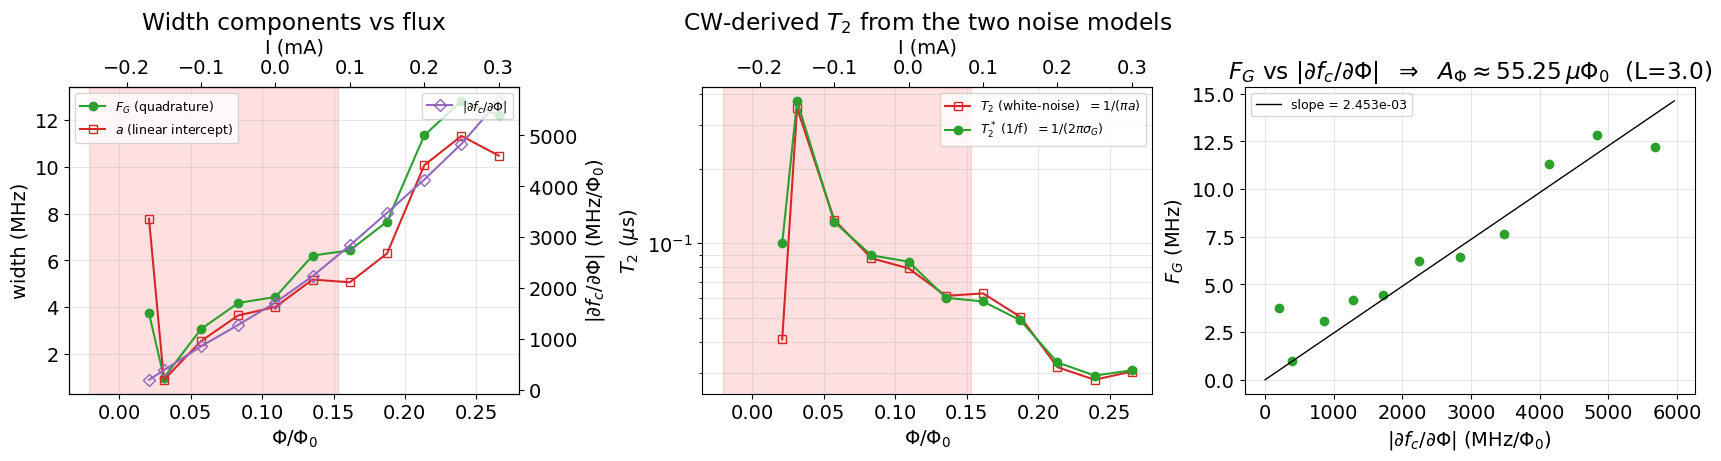

Per-current widths and CW T2 estimates:
     I[mA]   Phi/Phi0     a_lin       F_G    T2_white[us]    T2_1f*[us]   |df_c/dPhi|
   -0.1700    +0.0208     7.772     3.746          0.0410        0.1001         202.5
   -0.1500    +0.0312     0.904     0.995          0.3520        0.3768         389.3
   -0.1000    +0.0573     2.557     3.072          0.1245        0.1220         859.6
   -0.0500    +0.0833     3.652     4.185          0.0872        0.0896        1280.7
   +0.0000    +0.1094     4.013     4.438          0.0793        0.0844        1718.7
   +0.0500    +0.1354     5.181     6.208          0.0614        0.0604        2238.4
   +0.1000    +0.1615     5.066     6.430          0.0628        0.0583        2840.0
   +0.1500    +0.1875     6.296     7.657          0.0506        0.0489        3480.4
   +0.2000    +0.2135    10.063    11.335          0.0316        0.0331        4132.5
   +0.2500    +0.2396    11.313    12.809          0.0281        0.0293        4833.9
   +0.3000    

In [23]:
# --- Per-current Gaussian-floor + linear-intercept extraction across all spec_vs_power entries ---
char_dict = data.get('characterization', {})

def quad_model(g, F_G, c):
    return np.sqrt(F_G**2 + (c * g)**2)

def lin_model(g, a, b):
    return a + b * g

I_arr_diag, F_G_arr, c_pb_arr, a_lin_arr = [], [], [], []
for I_key, ent in char_dict.items():
    sp_e = ent.get('spec_vs_power')
    if sp_e is None: continue
    g_e = np.asarray(sp_e['gains'], dtype=float)
    f_e = np.asarray(sp_e['FWHMs'], dtype=float)
    msk = np.isfinite(g_e) & np.isfinite(f_e)
    if msk.sum() < 3: continue
    try:
        p_q, _ = opt.curve_fit(quad_model, g_e[msk], f_e[msk],
                                p0=[max(1e-3, f_e[msk].min()), 1e-4],
                                bounds=([0, 0], [np.inf, np.inf]))
        p_l, _ = opt.curve_fit(lin_model, g_e[msk], f_e[msk],
                                p0=[f_e[msk].min(), 1e-4])
        I_arr_diag.append(float(I_key))
        F_G_arr.append(float(p_q[0]))
        c_pb_arr.append(float(p_q[1]))
        a_lin_arr.append(float(p_l[0]))
    except Exception:
        pass

I_arr_diag = np.asarray(I_arr_diag)
F_G_arr    = np.asarray(F_G_arr)
c_pb_arr   = np.asarray(c_pb_arr)
a_lin_arr  = np.asarray(a_lin_arr)
order = np.argsort(I_arr_diag)
I_arr_diag, F_G_arr, c_pb_arr, a_lin_arr = (
    I_arr_diag[order], F_G_arr[order], c_pb_arr[order], a_lin_arr[order])

phi_diag = I_to_phi(I_arr_diag)
dfc_grad_dense = np.gradient(fc_d_grid, phi_grid_dense)
dfc_diag = np.interp(phi_diag, phi_grid_dense, dfc_grad_dense)

# --- T2 estimates per current ---
# White-noise (Lorentzian): FWHM_L = 1/(pi T2)  =>  T2[us] = 1/(pi * a_lin[MHz])
# 1/f (Gaussian):           sigma_f = F_G/2.355, T2*[us] = 1/(2 pi sigma_f[MHz])
with np.errstate(divide='ignore', invalid='ignore'):
    T2_white_arr = np.where(a_lin_arr > 0, 1.0 / (np.pi * a_lin_arr), np.nan)
    sigma_G_arr  = F_G_arr / 2.355
    T2_1f_arr    = np.where(sigma_G_arr > 0, 1.0 / (2.0 * np.pi * sigma_G_arr), np.nan)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(phi_diag, F_G_arr, 'o-', color='tab:green', label=r'$F_G$ (quadrature)')
ax.plot(phi_diag, a_lin_arr, 's-', color='tab:red', mfc='none', label=r'$a$ (linear intercept)')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel('width (MHz)')
ax2 = ax.twinx()
ax2.plot(phi_diag, np.abs(dfc_diag), 'D-', color='tab:purple', mfc='none',
         label=r'$|\partial f_c/\partial \Phi|$')
ax2.set_ylabel(r'$|\partial f_c/\partial\Phi|$ (MHz/$\Phi_0$)')
shade_hybrid(ax, label='_nolegend_')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax.set_title('Width components vs flux')
ax.grid(alpha=0.3)
add_current_top_axis(ax)

ax = axes[1]
ax.plot(phi_diag, T2_white_arr, 's-', color='tab:red',  mfc='none',
        label=r'$T_2$ (white-noise)  $=1/(\pi a)$')
ax.plot(phi_diag, T2_1f_arr,    'o-', color='tab:green',
        label=r'$T_2^*$ (1/f)  $=1/(2\pi\sigma_G)$')
ax.set_xlabel(r'$\Phi/\Phi_0$'); ax.set_ylabel(r'$T_2$ ($\mu$s)')
ax.set_yscale('log')
shade_hybrid(ax, label='_nolegend_')
ax.set_title('CW-derived $T_2$ from the two noise models')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
add_current_top_axis(ax)

ax = axes[2]
ax.plot(np.abs(dfc_diag), F_G_arr, 'o', color='tab:green')
sel = np.isfinite(F_G_arr) & np.isfinite(dfc_diag)
if sel.sum() >= 2:
    m_slope = float(np.sum(F_G_arr[sel] * np.abs(dfc_diag[sel])) /
                    np.sum(np.abs(dfc_diag[sel])**2))
    x_ = np.array([0.0, np.max(np.abs(dfc_diag[sel])) * 1.05])
    ax.plot(x_, m_slope * x_, '-', color='k', lw=1.0,
            label=f'slope = {m_slope:.3e}')
    L_assume = 3.0
    A_phi_lineshape_uPhi0 = m_slope / (2.355 * 2 * np.pi * L_assume) * 1e6
    ax.set_title(fr'$F_G$ vs $|\partial f_c/\partial\Phi|$  $\Rightarrow$  '
                 fr'$A_\Phi \approx {A_phi_lineshape_uPhi0:.2f}\,\mu\Phi_0$  (L={L_assume:.1f})')
ax.set_xlabel(r'$|\partial f_c/\partial\Phi|$ (MHz/$\Phi_0$)')
ax.set_ylabel(r'$F_G$ (MHz)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.show()

print('Per-current widths and CW T2 estimates:')
hdr = (f"  {'I[mA]':>8}  {'Phi/Phi0':>9}  {'a_lin':>8}  {'F_G':>8}  "
       f"{'T2_white[us]':>14}  {'T2_1f*[us]':>12}  {'|df_c/dPhi|':>12}")
print(hdr)
for I, a, fg, T2w, T21f, df in zip(I_arr_diag, a_lin_arr, F_G_arr,
                                    T2_white_arr, T2_1f_arr, dfc_diag):
    print(f'  {I:+8.4f}  {I_to_phi(I):+9.4f}  {a:8.3f}  {fg:8.3f}  '
          f'{T2w:14.4f}  {T21f:12.4f}  {abs(df):12.1f}')
